In [1]:
import pandas as pd
import glob
import os
import warnings
from pathlib import Path

# Disabilita warning
warnings.filterwarnings('ignore')

print("="*60)
print("1) CARICAMENTO DATASET FTMO (SMART PATH FINDER)")
print("="*60)

# --- FUNZIONE CERCA CARTELLA ---
def find_dataset_folder(folder_name):
    # Percorsi possibili da controllare
    possible_paths = [
        Path(folder_name),                       # 1. Nella cartella corrente
        Path("ftmo_challenge") / folder_name,    # 2. Dentro la cartella ftmo_challenge
        Path("..") / folder_name,                # 3. Nella cartella superiore
        Path("..") / "ftmo_challenge" / folder_name # 4. Superiore -> ftmo_challenge
    ]
    
    for p in possible_paths:
        if p.exists() and p.is_dir():
            return p
    return None

# --- ESECUZIONE ---
TARGET_FOLDER_NAME = 'ftmo_dataset'
found_path = find_dataset_folder(TARGET_FOLDER_NAME)

if found_path is None:
    print(f"❌ ERRORE CRITICO: Cartella '{TARGET_FOLDER_NAME}' non trovata!")
    print("   Assicurati di aver generato i file CSV con le strategie.")
    print("   Percorsi controllati: Cartella corrente, ftmo_challenge/, ../")
else:
    print(f"✅ Cartella dataset trovata in: {found_path}")
    
    # Cerca i file CSV usando il percorso trovato
    search_pattern = str(found_path / "*_returns.csv")
    files = glob.glob(search_pattern)
    
    if not files:
        print(f"⚠️ ATTENZIONE: La cartella esiste ma è VUOTA.")
    else:
        print(f"📂 Trovati {len(files)} asset da caricare.")

    # Inizializzazione DataFrame
    bnh_df = pd.DataFrame()
    strat_df = pd.DataFrame()
    tickers = []

    for f in files:
        # Estrai nome Ticker
        base_name = os.path.basename(f)
        ticker = base_name.replace('_returns.csv', '')
        tickers.append(ticker)
        
        # Leggi CSV
        df = pd.read_csv(f, index_col=0, parse_dates=True)
        
        # 1. Popola bnh_df (Prezzi) -> Rinomina colonna in "{TICKER}"
        col_close = f"{ticker}_Close"
        if col_close in df.columns:
            bnh_df[ticker] = df[col_close]
        
        # 2. Popola strat_df (Rendimenti e Posizioni)
        col_ret = f"{ticker}_Return"
        col_pos = f"{ticker}_Position"
        
        if col_ret in df.columns and col_pos in df.columns:
            strat_df[col_ret] = df[col_ret]
            strat_df[col_pos] = df[col_pos]

    # Pulizia e Allineamento
    bnh_df = bnh_df.dropna()
    strat_df = strat_df.loc[bnh_df.index]

    print(f"✅ Caricamento Completato per: {tickers}")
    print(f"📅 Periodo: {bnh_df.index[0].date()} -> {bnh_df.index[-1].date()}")
    print(f"📊 Shape Prezzi: {bnh_df.shape}")
    print(f"📊 Shape Strategia: {strat_df.shape}")
    
    print("-" * 60)
    print("Anteprima (Ultime 3 righe):")
    print(bnh_df.tail(3))

1) CARICAMENTO DATASET FTMO (SMART PATH FINDER)
✅ Cartella dataset trovata in: ftmo_challenge\ftmo_dataset
📂 Trovati 8 asset da caricare.
✅ Caricamento Completato per: ['AAPL', 'AMZN', 'GC=F', 'GOOG', 'META', 'MSFT', 'NFLX', 'NVDA']
📅 Periodo: 2018-01-03 -> 2025-12-16
📊 Shape Prezzi: (1999, 8)
📊 Shape Strategia: (1999, 16)
------------------------------------------------------------
Anteprima (Ultime 3 righe):
                  AAPL        AMZN         GC=F        GOOG        META  \
Date                                                                      
2025-12-12  278.279999  226.190002  4300.100098  310.519989  643.705017   
2025-12-15  274.109985  222.539993  4306.700195  309.320007  647.510010   
2025-12-16  274.609985  222.559998  4304.500000  307.730011  657.150024   

                  MSFT       NFLX        NVDA  
Date                                           
2025-12-12  478.529999  95.190002  175.020004  
2025-12-15  474.820007  93.769997  176.289993  
2025-12-16  476.39

2) ANALISI CORRELAZIONE ASSET
Matrice di Correlazione (Numerica):
      AAPL  AMZN  GC=F  GOOG  META  MSFT  NFLX  NVDA
AAPL  1.00  0.59  0.05  0.62  0.53  0.70  0.45  0.57
AMZN  0.59  1.00  0.03  0.64  0.61  0.68  0.55  0.58
GC=F  0.05  0.03  1.00  0.06  0.03  0.04  0.08  0.05
GOOG  0.62  0.64  0.06  1.00  0.61  0.71  0.45  0.57
META  0.53  0.61  0.03  0.61  1.00  0.61  0.48  0.53
MSFT  0.70  0.68  0.04  0.71  0.61  1.00  0.50  0.66
NFLX  0.45  0.55  0.08  0.45  0.48  0.50  1.00  0.47
NVDA  0.57  0.58  0.05  0.57  0.53  0.66  0.47  1.00


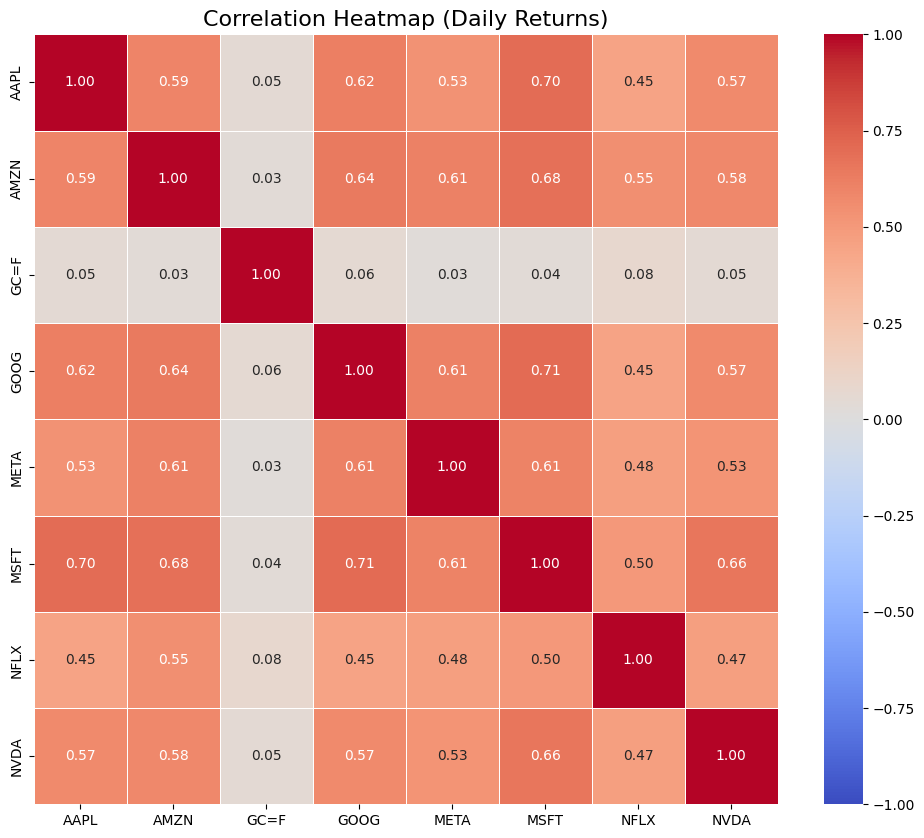


🔍 INSIGHT RAPIDO:
La correlazione minima nel portafoglio è: 0.03
✅ Buona diversificazione rilevata tra alcuni asset.


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 2) CORRELATION MATRIX & HEATMAP
# ============================================================

print("="*60)
print("2) ANALISI CORRELAZIONE ASSET")
print("="*60)

# bnh_df contiene i PREZZI. Per la correlazione servono i RENDIMENTI giornalieri.
# Se calcoli la correlazione sui prezzi, viene tutto falsato dal trend.
returns_df = bnh_df.pct_change().dropna()

# Calcolo Matrice di Correlazione
corr_matrix = returns_df.corr()

print("Matrice di Correlazione (Numerica):")
print(corr_matrix.round(2))

# --- PLOT HEATMAP ---
plt.figure(figsize=(12, 10))
plt.title('Correlation Heatmap (Daily Returns)', fontsize=16)

# Disegna la Heatmap
# annot=True mostra i numeri, cmap='coolwarm' fa rosso(corr)/blu(decorr)
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5, 
            vmin=-1, 
            vmax=1)

plt.show()

# Insight veloce per il trader
print("\n🔍 INSIGHT RAPIDO:")
# Trova la coppia con correlazione più bassa (migliore per diversificare)
min_corr = corr_matrix.min().min()
print(f"La correlazione minima nel portafoglio è: {min_corr:.2f}")
if min_corr > 0.7:
    print("⚠️ ATTENZIONE: Il portafoglio è molto correlato. Rischio sistemico alto.")
else:
    print("✅ Buona diversificazione rilevata tra alcuni asset.")

In [3]:
import talib

# ============================================================
# 3) CALCOLO RSI (MOMENTUM RANKING)
# ============================================================

# Copiamo il dataframe dei PREZZI (bnh_df)
bnh_df_rsi = bnh_df.copy()

# RSI Period: 90 è molto lento (Trend di fondo).
# Se vuoi uno Swing più reattivo, prova 28 o 14. 
# Per ora lasciamo 90 come da template originale.
RSI_PERIOD = 28 

print(f"Calculating RSI ({RSI_PERIOD}-period) on PRICES for Momentum Ranking...")

for ticker in bnh_df.columns:
    # PRENDIAMO I PREZZI (CLOSE)
    # Nota: L'RSI di momentum si calcola sul Prezzo o sul Cumulative Return.
    # NON calcolarlo sui 'daily returns' (% change), altrimenti ottieni solo rumore.
    price_data = bnh_df[ticker].values
    
    # Calcolo RSI
    rsi = talib.RSI(price_data, timeperiod=RSI_PERIOD)
    
    # Salviamo
    bnh_df_rsi[f'{ticker}_RSI'] = rsi

print(f"✅ RSI calcolato correttamente su {len(bnh_df.columns)} asset.")
print("-" * 60)

# Verifica visiva: Dovresti vedere valori tra 0 e 100 (spesso tra 40 e 80 in trend)
rsi_cols = [col for col in bnh_df_rsi.columns if '_RSI' in col]
print(bnh_df_rsi[rsi_cols].tail())

Calculating RSI (28-period) on PRICES for Momentum Ranking...
✅ RSI calcolato correttamente su 8 asset.
------------------------------------------------------------
             AAPL_RSI   AMZN_RSI   GC=F_RSI   GOOG_RSI   META_RSI   MSFT_RSI  \
Date                                                                           
2025-12-10  61.407209  51.277501  58.943689  67.471137  46.531593  42.834730   
2025-12-11  60.656766  50.438902  62.365378  63.435804  47.043666  44.734316   
2025-12-12  60.822271  48.209511  62.890926  61.766944  45.556505  43.235305   
2025-12-15  56.696646  46.314956  63.132283  61.137536  46.346387  42.135657   
2025-12-16  57.058829  46.326944  62.990652  60.293306  48.316480  42.774404   

             NFLX_RSI   NVDA_RSI  
Date                              
2025-12-10  33.145074  49.945192  
2025-12-11  34.838217  48.383495  
2025-12-12  36.174402  45.335092  
2025-12-15  35.207900  46.091988  
2025-12-16  36.203746  46.949713  


In [4]:
import numpy as np

# ============================================================
# 4) RSI RANKING SYSTEM (MOMENTUM FILTER)
# ============================================================

print("="*60)
print("4) GENERAZIONE RANKING (RSI > 50)")
print("="*60)

# Extract RSI columns
rsi_cols = [col for col in bnh_df_rsi.columns if '_RSI' in col]

# Create ranking dataframe
ranking_df = pd.DataFrame(index=bnh_df_rsi.index)

print(f"Processing {len(bnh_df_rsi)} trading days...")

# For each row (date), rank the RSI values
for idx, row in bnh_df_rsi.iterrows():
    # Get RSI values for this date
    # Drop NaNs immediately to avoid sorting issues
    row_clean = row[rsi_cols].dropna()
    
    if row_clean.empty:
        continue

    # Create dictionary for ranking
    ticker_rsi = {}
    for col in row_clean.index:
        ticker = col.replace('_RSI', '')
        rsi_val = row_clean[col]
        ticker_rsi[ticker] = rsi_val
    
    # Rank tickers by RSI (highest gets rank 1)
    # Reverse=True -> Dal più alto al più basso
    sorted_tickers = sorted(ticker_rsi.items(), key=lambda x: x[1], reverse=True)
    
    # Assign ranks
    for rank, (ticker, rsi_val) in enumerate(sorted_tickers, 1):
        # LOGICA FILTRO:
        # 1. Se RSI < 50 -> Rank 0 (Escluso, Trend Debole)
        # 2. Se RSI >= 50 -> Rank 1, 2, 3... (In Gara)
        if rsi_val < 50:
            ranking_df.loc[idx, f'{ticker}_Rank'] = 0
        else:
            ranking_df.loc[idx, f'{ticker}_Rank'] = rank

# Riempie i buchi rimasti (es. asset senza dati quel giorno) con 0
ranking_df = ranking_df.fillna(0)

print("\n✅ Ranking Completato.")
print("="*60)
print("Rules:")
print("  - Rank 1 = Asset più forte (RSI più alto)")
print("  - Rank 0 = Asset debole (RSI < 50) o Dati mancanti")
print("-" * 60)

# Mostriamo chi comanda oggi (Ultima riga disponibile)
last_date = ranking_df.index[-1]
print(f"Situazione Ranking al {last_date.date()}:")
last_row = ranking_df.loc[last_date]

# Filtra solo quelli con Rank > 0 e ordinali
active_ranks = last_row[last_row > 0].sort_values()
if active_ranks.empty:
    print("⚠️ NESSUN ASSET VALIDO (Tutti RSI < 50). Mercato Bearish?")
else:
    for col, rank in active_ranks.items():
        ticker = col.replace('_Rank', '')
        # Recupera il valore RSI per contesto
        rsi_val = bnh_df_rsi.loc[last_date, f'{ticker}_RSI']
        print(f"  #{int(rank)}: {ticker:<6} (RSI: {rsi_val:.1f})")

print("="*60)

4) GENERAZIONE RANKING (RSI > 50)
Processing 1999 trading days...

✅ Ranking Completato.
Rules:
  - Rank 1 = Asset più forte (RSI più alto)
  - Rank 0 = Asset debole (RSI < 50) o Dati mancanti
------------------------------------------------------------
Situazione Ranking al 2025-12-16:
  #1: GC=F   (RSI: 63.0)
  #2: GOOG   (RSI: 60.3)
  #3: AAPL   (RSI: 57.1)


In [5]:
# ============================================================
# 5) ALLINEAMENTO DATI STRATEGIA E RANKING
# ============================================================

print("="*60)
print("5) VERIFICA E ALLINEAMENTO STRAT_DF")
print("="*60)

# 1. Verifica esistenza
if strat_df.empty:
    raise ValueError("❌ ERRORE CRITICO: strat_df è vuoto. Rilancia il Passo 1.")

# 2. Allineamento Indici
# Vogliamo che strat_df (Rendimenti) e ranking_df (Classifica) abbiano le stesse date.
# L'intersezione degli indici rimuove i giorni dove mancano dati in uno dei due.
common_index = ranking_df.index.intersection(strat_df.index)

# Filtriamo entrambi
strat_df = strat_df.loc[common_index]
ranking_df = ranking_df.loc[common_index]

# 3. Verifica Colonne
# Identifichiamo le colonne di Posizione presenti
pos_cols = [c for c in strat_df.columns if '_Position' in c]
ret_cols = [c for c in strat_df.columns if '_Return' in c]

print(f"✅ Allineamento Completato.")
print(f"📅 Date Sincronizzate: {len(common_index)} giorni di trading")
print(f"   Inizio: {common_index[0].date()}")
print(f"   Fine:   {common_index[-1].date()}")
print(f"📊 Asset Monitorati: {len(pos_cols)}")
print("-" * 60)

# 4. Anteprima Dinamica
# Prende i primi 2 asset trovati (invece di cercare TQQQ o ESPO che non hai)
print("Anteprima Dati (Position & Return):")
if len(tickers) >= 2:
    example_tickers = tickers[:2] # Prende i primi due (es. AAPL, NVDA)
    cols_to_show = []
    for t in example_tickers:
        cols_to_show.append(f'{t}_Position')
        cols_to_show.append(f'{t}_Return')
    
    # Filtra solo le colonne che esistono davvero
    valid_cols = [c for c in cols_to_show if c in strat_df.columns]
    print(strat_df[valid_cols].tail())
else:
    print(strat_df.tail())

print("="*60)

5) VERIFICA E ALLINEAMENTO STRAT_DF
✅ Allineamento Completato.
📅 Date Sincronizzate: 1999 giorni di trading
   Inizio: 2018-01-03
   Fine:   2025-12-16
📊 Asset Monitorati: 8
------------------------------------------------------------
Anteprima Dati (Position & Return):
            AAPL_Position  AAPL_Return  AMZN_Position  AMZN_Return
Date                                                              
2025-12-10              0     0.005772            1.0     0.016936
2025-12-11              0    -0.002690            1.0    -0.006472
2025-12-12              0     0.000899            1.0    -0.017761
2025-12-15              0    -0.014985            1.0    -0.016137
2025-12-16              0     0.001824            1.0     0.000090


In [6]:
# ============================================================
# 6) CREAZIONE MASTER DATAFRAME (ALL-IN-ONE)
# ============================================================

print("="*60)
print("6) MERGE FINALE: SEGNALI + RANKING + PREZZI")
print("="*60)

# 1. Converti indici in datetime (sicurezza)
ranking_df.index = pd.to_datetime(ranking_df.index)
strat_df.index = pd.to_datetime(strat_df.index)
bnh_df.index = pd.to_datetime(bnh_df.index)

# 2. Merge Base: Strategia (Position/Return) + Ranking
combined_df = strat_df.join(ranking_df, how='inner')

# 3. AGGIUNTA FONDAMENTALE: I Prezzi (Close)
# bnh_df ha le colonne col nome del ticker (es. "NVDA"). 
# Le rinominiamo in "NVDA_Close" per non confonderci e le uniamo.
price_df_renamed = bnh_df.add_suffix('_Close')
combined_df = combined_df.join(price_df_renamed, how='inner')

# 4. Verifica Finale
if combined_df.empty:
    print("⚠️ ATTENZIONE: Il DataFrame combinato è VUOTO! Verifica le date dei CSV.")
else:
    print(f"✅ Master DataFrame Creato.")
    print(f"📊 Dimensioni: {combined_df.shape}")
    print(f"📅 Periodo: {combined_df.index[0].date()} -> {combined_df.index[-1].date()}")
    print("-" * 60)

    # 5. Visualizzazione Intelligente (Solo per il primo asset)
    # Invece di stampare tutto il caos, vediamo se per UN asset c'è tutto.
    if len(tickers) > 0:
        sample = tickers[0] # Es. NVDA
        cols_to_check = [
            f'{sample}_Close',    # Prezzo (Serve per i lotti)
            f'{sample}_Return',   # Rendimento (Serve per l'equity)
            f'{sample}_Position', # Segnale (Serve per entrare)
            f'{sample}_Rank'      # RSI (Serve per scegliere)
        ]
        # Filtra solo le colonne esistenti
        valid_cols = [c for c in cols_to_check if c in combined_df.columns]
        
        print(f"Esempio Dati Allineati per {sample}:")
        print(combined_df[valid_cols].tail(10))

print("="*60)

6) MERGE FINALE: SEGNALI + RANKING + PREZZI
✅ Master DataFrame Creato.
📊 Dimensioni: (1999, 32)
📅 Periodo: 2018-01-03 -> 2025-12-16
------------------------------------------------------------
Esempio Dati Allineati per AAPL:
            AAPL_Close  AAPL_Return  AAPL_Position  AAPL_Rank
Date                                                         
2025-12-03  284.149994    -0.007128              1        2.0
2025-12-04  280.700012    -0.012141              1        2.0
2025-12-05  278.779999    -0.006840              1        2.0
2025-12-08  277.890015    -0.003192              1        2.0
2025-12-09  277.179993    -0.002555              1        2.0
2025-12-10  278.779999     0.005772              0        2.0
2025-12-11  278.029999    -0.002690              0        3.0
2025-12-12  278.279999     0.000899              0        3.0
2025-12-15  274.109985    -0.014985              0        3.0
2025-12-16  274.609985     0.001824              0        3.0


In [7]:
import numpy as np

# ============================================================
# STEP 1: PARAMETRI E VALIDAZIONE (FTMO CONFIG)
# ============================================================

# --- PARAMETRI UTENTE ---
TOP_N = 4         # Selezioniamo i migliori 3 asset (su 8 totali)
SAFE_HAVEN = 'GC=F' # Usiamo l'Oro come rifugio (se gli stock crollano)

print("="*80)
print("STEP 1: CONFIGURAZIONE PARAMETRI")
print("="*80)
print(f"🏆 Top N Assets: {TOP_N}")
print(f"🛡️ Safe Haven:   {SAFE_HAVEN}")
print(f"⚖️ Peso Max per Asset: {1.0/TOP_N:.2%} (Allocazione teorica)")
print("-" * 80)

# 1. Recupera la lista dei Ticker dalle colonne Rank
rank_cols = [col for col in combined_df.columns if '_Rank' in col]
tickers = [col.replace('_Rank', '') for col in rank_cols]

print(f"📦 Asset Disponibili ({len(tickers)}):")
print(f"   {', '.join(tickers)}")
print()

# 2. Controllo Disponibilità Safe Haven
if SAFE_HAVEN not in tickers:
    print(f"⚠️ ATTENZIONE: Il Safe Haven '{SAFE_HAVEN}' NON è nella lista dei ticker!")
    print("   Se non ci sono abbastanza stock validi, il sistema resterà CASH.")
    SAFE_HAVEN_EXISTS = False
else:
    print(f"✅ Safe Haven '{SAFE_HAVEN}' rilevato e pronto all'uso.")
    SAFE_HAVEN_EXISTS = True

print("-" * 80)

# 3. Verifica Integrità Dati (Check Colonne)
print("Verifica Colonne (Deve essere tutto True):")
missing_data = False
for ticker in tickers:
    # Costruiamo i nomi delle colonne attese
    rank_col = f'{ticker}_Rank'
    pos_col = f'{ticker}_Position'
    ret_col = f'{ticker}_Return'
    close_col = f'{ticker}_Close' # Verifica anche il Prezzo!
    
    # Controlliamo se esistono
    has_rank = rank_col in combined_df.columns
    has_pos = pos_col in combined_df.columns
    has_ret = ret_col in combined_df.columns
    has_close = close_col in combined_df.columns
    
    # Stampa di controllo
    status = "✅" if (has_rank and has_pos and has_ret and has_close) else "❌"
    if status == "❌": missing_data = True
    
    print(f" {status} {ticker:<6} | Rank:{str(has_rank):<5} Pos:{str(has_pos):<5} Ret:{str(has_ret):<5} Close:{str(has_close):<5}")

if missing_data:
    raise ValueError("⛔ ERRORE: Mancano alcune colonne fondamentali (vedi sopra). Controlla il caricamento.")
else:
    print(f"\n✅ Validazione Completata: Tutti i dati sono pronti per il Backtest.")

STEP 1: CONFIGURAZIONE PARAMETRI
🏆 Top N Assets: 4
🛡️ Safe Haven:   GC=F
⚖️ Peso Max per Asset: 25.00% (Allocazione teorica)
--------------------------------------------------------------------------------
📦 Asset Disponibili (8):
   NFLX, AMZN, NVDA, GC=F, MSFT, GOOG, META, AAPL

✅ Safe Haven 'GC=F' rilevato e pronto all'uso.
--------------------------------------------------------------------------------
Verifica Colonne (Deve essere tutto True):
 ✅ NFLX   | Rank:True  Pos:True  Ret:True  Close:True 
 ✅ AMZN   | Rank:True  Pos:True  Ret:True  Close:True 
 ✅ NVDA   | Rank:True  Pos:True  Ret:True  Close:True 
 ✅ GC=F   | Rank:True  Pos:True  Ret:True  Close:True 
 ✅ MSFT   | Rank:True  Pos:True  Ret:True  Close:True 
 ✅ GOOG   | Rank:True  Pos:True  Ret:True  Close:True 
 ✅ META   | Rank:True  Pos:True  Ret:True  Close:True 
 ✅ AAPL   | Rank:True  Pos:True  Ret:True  Close:True 

✅ Validazione Completata: Tutti i dati sono pronti per il Backtest.


In [ ]:
# ============================================================
# STEP 2: DYNAMIC ALLOCATION LOGIC (1-DAY LAG WITH CONFIRMATION)
# ============================================================

print("="*80)
print("STEP 2: DYNAMIC ASSET ALLOCATION (1-DAY LAG + CONFIRMATION)")
print("="*80)

# Initialize allocation dataframe
allocation_df = pd.DataFrame(index=combined_df.index)

# Initialize weight columns for all tickers to 0.0
for ticker in tickers:
    allocation_df[f'{ticker}_Weight'] = 0.0

# Helper utilities
weight_per_slot = 1.0 / TOP_N

def build_selection(row_date):
    """Sceglie gli asset per una data specifica in base a Rank e Position"""
    eligible_assets = []
    
    for ticker in tickers:
        # Recupera Rank e Posizione per quella data
        rank = combined_df.loc[row_date, f'{ticker}_Rank']
        position = combined_df.loc[row_date, f'{ticker}_Position']
        
        # LOGICA STOCK:
        # Deve essere nei Top N (Rank <= TOP_N) e avere segnale attivo (Position == 1)
        # Escludiamo il Safe Haven da questa prima selezione
        if ticker != SAFE_HAVEN:
            if rank >= 1 and rank <= TOP_N and position == 1:
                eligible_assets.append((ticker, rank))
    
    # Ordina per Rank (dal migliore al peggiore)
    eligible_assets.sort(key=lambda x: x[1])
    selected = [t for t, _ in eligible_assets]
    
    # Taglia ai primi TOP_N se ce ne sono troppi (ridondante col check sopra ma sicuro)
    selected = selected[:TOP_N]

    # LOGICA SAFE HAVEN (Riempimento Buchi)
    slots_needed = TOP_N - len(selected)
    
    if slots_needed > 0 and SAFE_HAVEN in tickers:
        safe_rank = combined_df.loc[row_date, f'{SAFE_HAVEN}_Rank']
        safe_pos = combined_df.loc[row_date, f'{SAFE_HAVEN}_Position']
        
        # L'oro entra se ha segnale (Pos=1) e non è in crash (Rank > 0)
        # Non serve che sia Top 4, basta che sia sano.
        if safe_rank >= 1 and safe_pos == 1:
            selected.extend([SAFE_HAVEN] * slots_needed)
            
    return selected

def apply_weights(row_date, assets):
    """Scrive i pesi nel DataFrame"""
    if not assets:
        return
    
    weight_allocation = {}
    # Conta quante volte un asset appare (es. Oro può riempire 2 slot -> 66%)
    for ticker in assets:
        weight_allocation[ticker] = weight_allocation.get(ticker, 0.0) + weight_per_slot
        
    for ticker, weight in weight_allocation.items():
        allocation_df.loc[row_date, f'{ticker}_Weight'] = weight

# --- MAIN LOOP ---
allocation_history = []
prev_allocated = []

print(f"Processing {len(combined_df)} days...\n")

for i in range(len(combined_df)):
    current_date = combined_df.index[i]
    
    # Reset pesi a 0 per sicurezza
    for ticker in tickers:
        allocation_df.loc[current_date, f'{ticker}_Weight'] = 0.0

    # Primi 2 giorni non possiamo fare Lag+Confirmation
    if i < 2:
        continue

    # Date precedenti per la logica di conferma
    prev_date = combined_df.index[i - 1]
    confirm_date = combined_df.index[i - 2]
    
    # 1. Calcola i candidati per ieri e l'altro ieri
    candidate_prev = build_selection(prev_date)
    candidate_confirm = build_selection(confirm_date)
    
    # 2. SELEZIONE DEFINITIVA
    # Se la selezione è stabile per 2 giorni -> Cambia allocazione
    if set(candidate_prev) == set(candidate_confirm):
        selected_assets = candidate_prev
    else:
        # Se c'è instabilità, manteniamo l'allocazione precedente (prev_allocated)
        # MA dobbiamo controllare che gli asset vecchi siano ancora validi oggi!
        # (Es. se NVDA era in ptf ma oggi il segnale si spegne, deve uscire subito)
        kept_assets = []
        for asset in prev_allocated:
            # Check validità odierna (Rank > 0 e Posizione = 1)
            rnk = combined_df.loc[current_date, f'{asset}_Rank']
            pos = combined_df.loc[current_date, f'{asset}_Position']
            if rnk >= 1 and pos == 1:
                kept_assets.append(asset)
        
        selected_assets = kept_assets
        
        # Se abbiamo perso pezzi, proviamo a riempire con Safe Haven fresco
        slots_gap = TOP_N - len(selected_assets)
        if slots_gap > 0 and SAFE_HAVEN in tickers:
             safe_rnk = combined_df.loc[current_date, f'{SAFE_HAVEN}_Rank']
             safe_pos = combined_df.loc[current_date, f'{SAFE_HAVEN}_Position']
             if safe_rnk >= 1 and safe_pos == 1:
                 selected_assets.extend([SAFE_HAVEN] * slots_gap)

    # 3. Applica i pesi
    if selected_assets:
        apply_weights(current_date, selected_assets)

    # 4. Registra cambiamenti (Log)
    # Ordiniamo le liste per confrontarle correttamente
    if sorted(selected_assets) != sorted(prev_allocated):
        allocation_history.append({
            'date': current_date,
            'from': prev_allocated if prev_allocated else ['CASH'],
            'to': selected_assets.copy() if selected_assets else ['CASH']
        })
    
    prev_allocated = selected_assets.copy()

# --- METRICHE FINALI ---
weight_cols = [col for col in allocation_df.columns if '_Weight' in col]
allocation_df['Total_Weight'] = allocation_df[weight_cols].sum(axis=1)

cash_days = (allocation_df['Total_Weight'] == 0).sum()
full_days = (allocation_df['Total_Weight'] >= 0.99).sum()

print(f"✅ Step 2 Complete")
print(f"\nAllocation Summary:")
print(f"  Total Days: {len(allocation_df)}")
print(f"  Days in Cash (0%): {cash_days} ({cash_days/len(allocation_df):.1%})")
print(f"  Days Fully Invested: {full_days} ({full_days/len(allocation_df):.1%})")
print(f"  Allocation Changes: {len(allocation_history)}")

safe_days = (allocation_df[f'{SAFE_HAVEN}_Weight'] > 0).sum() if f'{SAFE_HAVEN}_Weight' in allocation_df.columns else 0
print(f"  Days with {SAFE_HAVEN}: {safe_days}")

print("\nSample Allocations (Last 10 Days):")
print(allocation_df[weight_cols + ['Total_Weight']].tail(10).round(2))

STEP 2: DYNAMIC ASSET ALLOCATION (1-DAY LAG + CONFIRMATION)
Processing 1999 days...

✅ Step 2 Complete

Allocation Summary:
  Total Days: 1999
  Days in Cash (0%): 242 (12.1%)
  Days Fully Invested: 1224 (61.2%)
  Allocation Changes: 376
  Days with GC=F: 708

Sample Allocations (Last 10 Days):
            NFLX_Weight  AMZN_Weight  NVDA_Weight  GC=F_Weight  MSFT_Weight  \
Date                                                                          
2025-12-03          0.0         0.25          0.0         0.50          0.0   
2025-12-04          0.0         0.25          0.0         0.25          0.0   
2025-12-05          0.0         0.00          0.0         0.50          0.0   
2025-12-08          0.0         0.00          0.0         0.50          0.0   
2025-12-09          0.0         0.00          0.0         0.50          0.0   
2025-12-10          0.0         0.00          0.0         0.50          0.0   
2025-12-11          0.0         0.00          0.0         0.75          

In [9]:
import random

# ==============================================================================
# SANITY CHECK INTEGRALE: FILIERA COMPLETA DA T-2 A T+2 (LOGICA TREND-FIRST)
# ==============================================================================

print("="*80)
print("SANITY CHECK: VERIFICA PERSISTENZA E ROTAZIONE (T-2 -> T+2)")
print("="*80)

# Impostiamo il seed per la riproducibilità
random.seed(42)
# Prendi 10 giorni a caso dal backtest
sample_indices = sorted(random.sample(range(len(allocation_df)), min(10, len(allocation_df))))

print(f"\n🔍 CONTROLLO DETTAGLIATO (Campione di 10 giorni casuali):")
print(f"   Target: Top {TOP_N} Asset | Safe Haven: {SAFE_HAVEN}")

for idx_pos in sample_indices:
    idx = allocation_df.index[idx_pos] # Data Corrente T
    
    print("-" * 80)
    print(f"📅 DATA ANALISI PRINCIPALE (T): {idx.date()}")
    
    # --- 1. DIAGNOSTICA PASSATA (Perché abbiamo queste posizioni oggi?) ---
    if idx_pos >= 2:
        idx_t_1 = allocation_df.index[idx_pos - 1] 
        idx_t_2 = allocation_df.index[idx_pos - 2] 
        try:
            c_t1 = build_selection(idx_t_1)
            c_t2 = build_selection(idx_t_2)
            stable_t = set(c_t1) == set(c_t2)
            print(f"   🕒 PASSATO (Decisione presa per T):")
            print(f"      [T-2] {idx_t_2.date()} -> {c_t2}")
            print(f"      [T-1] {idx_t_1.date()} -> {c_t1}")
            print(f"      ⚡ STATO A T: {'✅ STABILE (Cambio/Conferma)' if stable_t else '⚠️ INSTABILE (Mantenimento)'}")
        except: pass

    # --- 2. VERIFICA ASSET ALLOCATI (STATO ATTUALE T) ---
    print(f"   💼 PORTAFOGLIO EFFETTIVO A T:")
    allocated_count = 0
    total_slots = 0
    
    for ticker in tickers:
        rank = combined_df.loc[idx, f'{ticker}_Rank']
        position = combined_df.loc[idx, f'{ticker}_Position']
        weight = allocation_df.loc[idx, f'{ticker}_Weight']
        
        if weight > 0.001:
            allocated_count += 1
            slots = round(weight / (1.0/TOP_N))
            total_slots += slots
            status = "✅ INVESTED" + (" (SAFE HAVEN)" if ticker == SAFE_HAVEN else "")
        else:
            status = "·" 
        
        # Stampa ticker se allocato o se è un buon candidato
        if weight > 0 or (rank > 0 and rank <= TOP_N):
             print(f"      {ticker:8} | Rank: {rank:2.0f} | Pos: {position:1.0f} | Wgt: {weight:5.1%} | {status}")
        
        # --- SANITY CHECKS (VERSIONE RICALIBRATA) ---
        if weight > 0:
            # 1. ERRORE CRITICO: Trend finito ma ancora investito
            if position == 0 and ticker != SAFE_HAVEN:
                print(f"         ⛔ TREND FINITO: {ticker} Position=0 ma ancora in pancia!")
            
            # 2. HOLDING: Momentum basso (RSI < 50) ma trend ancora attivo
            if rank == 0 and position == 1 and ticker != SAFE_HAVEN:
                print(f"         🔄 HOLDING TREND: {ticker} Rank=0 (Low Momentum)")
            
            # 3. HOLDING: Fuori dai Top 4 per instabilità ma trend ancora attivo
            if rank > TOP_N and position == 1 and ticker != SAFE_HAVEN:
                print(f"         🔄 HOLDING TREND: {ticker} Rank {rank} > {TOP_N} (Attesa rotazione stabile)")
            
            # Verifica peso irregolare
            expected_slots = round(weight / (1.0/TOP_N))
            expected_weight = expected_slots * (1.0/TOP_N)
            if abs(weight - expected_weight) > 0.01:
                print(f"         ⚠️ WARNING: Peso {weight:.2%} irregolare")

    # --- 3. PROIEZIONE ROTAZIONE (COSA SUCCEDERÀ A T+1 E T+2) ---
    print(f"   🔮 PROIEZIONE ROTAZIONE (T+1 & T+2):")
    
    # Proiezione T+1 (basata su T e T-1)
    if idx_pos < len(allocation_df) - 1:
        idx_next_1 = allocation_df.index[idx_pos + 1]
        try:
            cand_t = build_selection(idx)
            cand_t_1 = build_selection(idx_t_1)
            stable_t1 = set(cand_t) == set(cand_t_1)
            print(f"      👉 Decisione per domani T+1 ({idx_next_1.date()}): {'🔄 CAMBIO/CONFERMA' if stable_t1 else '✋ PERSISTENZA'}")
            print(f"         (Confronto: {cand_t_1} vs {cand_t})")
        except: pass

    # Proiezione T+2 (basata su T+1 e T)
    if idx_pos < len(allocation_df) - 2:
        idx_next_1 = allocation_df.index[idx_pos + 1]
        idx_next_2 = allocation_df.index[idx_pos + 2]
        try:
            cand_t_plus_1 = build_selection(idx_next_1)
            cand_t_corrente = build_selection(idx) # Già calcolato sopra
            stable_t2 = set(cand_t_plus_1) == set(cand_t_corrente)
            print(f"      👉 Decisione per T+2 ({idx_next_2.date()}): {'🔄 CAMBIO/CONFERMA' if stable_t2 else '✋ PERSISTENZA'}")
            print(f"         (Confronto: {cand_t_corrente} vs {cand_t_plus_1})")
            
            w_sum_t2 = allocation_df.loc[idx_next_2, 'Total_Weight']
            print(f"      📊 RISULTATO REALE A T+2: Peso Totale {w_sum_t2:.1%}")
        except: pass

    # Riepilogo Giornaliero
    total_weight = allocation_df.loc[idx, 'Total_Weight']
    print(f"   {'SUMMARY':8} | Tot Wgt: {total_weight:.1%} | Assets: {allocated_count} | Slots: {total_slots}/{TOP_N}")
    if total_weight < 0.01:
        print(f"      ⚪ 100% CASH")
    elif abs(total_weight - 1.0) > 0.01:
        cash_pct = (1.0 - total_weight) * 100
        print(f"      🟡 ALLOCAZIONE PARZIALE: {cash_pct:.1f}% Cash")
    print()

# --- 4. STATISTICHE GLOBALI FINALI (INTEGRALI) ---
print("\n📊 STATISTICHE GLOBALI ALLOCAZIONE:\n")
print(f"Giorni Totali: {len(allocation_df)}")
print(f"Cambi Allocazione: {len(allocation_history)}")
print(f"Giorni con {SAFE_HAVEN}: {(allocation_df[f'{SAFE_HAVEN}_Weight'] > 0).sum()}")
print(f"Giorni 100% Investiti: {(allocation_df['Total_Weight'] >= 0.99).sum()}")
print(f"Giorni Parzialmente Investiti: {((allocation_df['Total_Weight'] < 0.99) & (allocation_df['Total_Weight'] > 0)).sum()}")
print(f"Giorni 100% Cash: {(allocation_df['Total_Weight'] == 0).sum()}")
print()

# Partecipazione Ticker
print("📈 PARTECIPAZIONE ASSET:\n")
for ticker in tickers:
    weight_col = f'{ticker}_Weight'
    days_held = (allocation_df[weight_col] > 0).sum()
    pct_days = days_held / len(allocation_df) * 100
    avg_weight = allocation_df[weight_col].mean()
    max_weight = allocation_df[weight_col].max()
    print(f"  {ticker:8} | Giorni: {days_held:4d} ({pct_days:5.1f}%) | Peso Medio: {avg_weight:6.2%} | Max Peso: {max_weight:6.2%}")

print(f"\n✅ Sanity Check Completato")

SANITY CHECK: VERIFICA PERSISTENZA E ROTAZIONE (T-2 -> T+2)

🔍 CONTROLLO DETTAGLIATO (Campione di 10 giorni casuali):
   Target: Top 4 Asset | Safe Haven: GC=F
--------------------------------------------------------------------------------
📅 DATA ANALISI PRINCIPALE (T): 2018-03-20
   🕒 PASSATO (Decisione presa per T):
      [T-2] 2018-03-16 -> []
      [T-1] 2018-03-19 -> []
      ⚡ STATO A T: ✅ STABILE (Cambio/Conferma)
   💼 PORTAFOGLIO EFFETTIVO A T:
      NFLX     | Rank:  2 | Pos: 1 | Wgt:  0.0% | ·
      AMZN     | Rank:  1 | Pos: 0 | Wgt:  0.0% | ·
      NVDA     | Rank:  3 | Pos: 0 | Wgt:  0.0% | ·
      MSFT     | Rank:  4 | Pos: 1 | Wgt:  0.0% | ·
   🔮 PROIEZIONE ROTAZIONE (T+1 & T+2):
      👉 Decisione per domani T+1 (2018-03-21): ✋ PERSISTENZA
         (Confronto: [] vs ['NFLX', 'MSFT'])
      👉 Decisione per T+2 (2018-03-22): ✋ PERSISTENZA
         (Confronto: ['NFLX', 'MSFT'] vs [])
      📊 RISULTATO REALE A T+2: Peso Totale 0.0%
   SUMMARY  | Tot Wgt: 0.0% | Assets: 0 | 

In [10]:
# ============================================================
# FOCUS ANALISI: CRASH COVID 2020 (LOGICA DI PERSISTENZA)
# ============================================================

import pandas as pd

# Definiamo il range temporale del crash
start_focus = "2020-03-20"
end_focus = "2020-04-10"

# Filtriamo i dati
focus_range = combined_df.loc[start_focus:end_focus].index

print("="*90)
print(f"🕵️ FOCUS ANALISI: COMPORTAMENTO DURANTE IL CRASH (Marzo/Aprile 2020)")
print("Obiettivo: Capire perché il bot non ha venduto AMZN/NVDA quando il Rank è sceso a 0")
print("="*90)

for current_date in focus_range:
    # 1. Recupero date per la logica di lag
    idx_pos = combined_df.index.get_loc(current_date)
    if idx_pos < 2: continue
    
    t_minus_1 = combined_df.index[idx_pos - 1]
    t_minus_2 = combined_df.index[idx_pos - 2]
    
    # 2. Cosa vedeva il bot nel passato per decidere OGGI
    cand_t1 = build_selection(t_minus_1)
    cand_t2 = build_selection(t_minus_2)
    is_stable = set(cand_t1) == set(cand_t2)
    
    print(f"\n📅 DATA: {current_date.date()}")
    print(f"   Step A - Diagnostica Input:")
    print(f"      T-2 ({t_minus_2.date()}) Candidati: {cand_t2}")
    print(f"      T-1 ({t_minus_1.date()}) Candidati: {cand_t1}")
    print(f"      ⚡ STATO LOGICO: {'✅ STABILE (Eseguo candidati T-1)' if is_stable else '⚠️ INSTABILE (Mantengo vecchie posizioni)'}")
    
    print(f"   Step B - Situazione Mercato Reale a T (Oggi):")
    for ticker in tickers:
        rank = combined_df.loc[current_date, f'{ticker}_Rank']
        pos = combined_df.loc[current_date, f'{ticker}_Position']
        weight = allocation_df.loc[current_date, f'{ticker}_Weight']
        
        if weight > 0 or (ticker in ['AMZN', 'NVDA', 'NFLX', 'GC=F']):
            status = " [ALLOCATO]" if weight > 0 else " [VUOTO]"
            alert = " 🚨 RANK 0!" if rank == 0 and weight > 0 else ""
            print(f"      - {ticker:6} | Rank: {rank} | Pos: {pos} | Wgt: {weight:5.1%}{status}{alert}")
            
    # 3. Spiegazione dell'azione
    if is_stable:
        reason = f"Il bot ha applicato la lista di ieri perché stabile. AMZN/NVDA erano nei candidati di ieri."
    else:
        reason = "Il bot ha 'congelato' il portafoglio precedente perché la classifica è cambiata."
    
    total_w = allocation_df.loc[current_date, 'Total_Weight']
    print(f"   🚀 CONCLUSIONE: {reason}")
    print(f"      Totale Investito: {total_w:.1%}")
    print("-" * 50)

print("\n✅ Analisi completata. Osserva come il bot 'subisce' il cambio di Rank a T perché la sua decisione era già presa a T-1.")

🕵️ FOCUS ANALISI: COMPORTAMENTO DURANTE IL CRASH (Marzo/Aprile 2020)
Obiettivo: Capire perché il bot non ha venduto AMZN/NVDA quando il Rank è sceso a 0

📅 DATA: 2020-03-20
   Step A - Diagnostica Input:
      T-2 (2020-03-18) Candidati: []
      T-1 (2020-03-19) Candidati: []
      ⚡ STATO LOGICO: ✅ STABILE (Eseguo candidati T-1)
   Step B - Situazione Mercato Reale a T (Oggi):
      - NFLX   | Rank: 0.0 | Pos: 1.0 | Wgt:  0.0% [VUOTO]
      - AMZN   | Rank: 0.0 | Pos: 1.0 | Wgt:  0.0% [VUOTO]
      - NVDA   | Rank: 0.0 | Pos: 0.0 | Wgt:  0.0% [VUOTO]
      - GC=F   | Rank: 0.0 | Pos: 0.0 | Wgt:  0.0% [VUOTO]
   🚀 CONCLUSIONE: Il bot ha applicato la lista di ieri perché stabile. AMZN/NVDA erano nei candidati di ieri.
      Totale Investito: 0.0%
--------------------------------------------------

📅 DATA: 2020-03-23
   Step A - Diagnostica Input:
      T-2 (2020-03-19) Candidati: []
      T-1 (2020-03-20) Candidati: []
      ⚡ STATO LOGICO: ✅ STABILE (Eseguo candidati T-1)
   Step B - 

In [11]:
# ==============================================================================
# AUDIT DI SICUREZZA: VERIFICA SEQUENZA DI USCITA (T-1 -> T -> T+1)
# ==============================================================================

print("="*90)
print("AUDIT DI SICUREZZA: ANALISI DEL TIMING DI USCITA")
print("Obiettivo: Verificare che il trend sia stato troncato esattamente dopo il segnale")
print("="*90)

anomaly_found = False

# Partiamo dall'indice 1 per poter guardare T-1
for i in range(1, len(allocation_df) - 1):
    idx_prev = allocation_df.index[i - 1] # T-1
    idx = allocation_df.index[i]          # T
    idx_next = allocation_df.index[i + 1] # T+1
    
    for ticker in tickers:
        if ticker == SAFE_HAVEN: continue
            
        weight_t = allocation_df.loc[idx, f'{ticker}_Weight']
        pos_t = combined_df.loc[idx, f'{ticker}_Position']
        
        # Individuiamo il momento in cui siamo dentro (Weight > 0) ma il segnale è 0
        if weight_t > 0.001 and pos_t == 0:
            anomaly_found = True
            print(f"🔍 ANALISI USCITA PER {ticker}:")
            
            # GIORNO T-1: Stato precedente (Dovrebbe essere Pos: 1)
            pos_prev = combined_df.loc[idx_prev, f'{ticker}_Position']
            w_prev = allocation_df.loc[idx_prev, f'{ticker}_Weight']
            print(f"   [T-1] {idx_prev.date()} | Pos: {pos_prev} | Wgt: {w_prev:5.1%} | (Stato Precedente)")
            
            # GIORNO T: Il segnale di vendita appare
            print(f"   [T]   {idx.date()} | Pos: {pos_t} | Wgt: {weight_t:5.1%} | ⚠️ SEGNALE VENDITA")
            
            # GIORNO T+1: Il bot deve aver eseguito la chiusura
            w_next = allocation_df.loc[idx_next, f'{ticker}_Weight']
            p_next = combined_df.loc[idx_next, f'{ticker}_Position']
            status = "✅ CHIUSO CORRETTAMENTE" if w_next < 0.001 else "❌ ERRORE: USCITA FALLITA"
            
            print(f"   [T+1] {idx_next.date()} | Pos: {p_next} | Wgt: {w_next:5.1%} | {status}")
            
            # Diagnostica extra se l'uscita è fallita
            if w_next > 0.001:
                # Controlliamo se per caso è colpa dell'instabilità della classifica
                c_t = build_selection(idx)
                c_prev = build_selection(idx_prev)
                if set(c_t) != set(c_prev):
                    print(f"      👉 NOTA: L'uscita è stata bloccata dalla LOGICA DI INSTABILITÀ.")
            
            print("-" * 60)

if not anomaly_found:
    print("✨ NESSUNA ANOMALIA: Il bot ha sempre chiuso le posizioni a T+1 dopo un segnale 0 a T.")
else:
    print("⚠️ AUDIT COMPLETATO: Verifica se le mancate uscite coincidono con periodi di alta volatilità.")

AUDIT DI SICUREZZA: ANALISI DEL TIMING DI USCITA
Obiettivo: Verificare che il trend sia stato troncato esattamente dopo il segnale
🔍 ANALISI USCITA PER NFLX:
   [T-1] 2018-02-15 | Pos: 1.0 | Wgt:  0.0% | (Stato Precedente)
   [T]   2018-02-16 | Pos: 0.0 | Wgt: 25.0% | ⚠️ SEGNALE VENDITA
   [T+1] 2018-02-20 | Pos: 0.0 | Wgt:  0.0% | ✅ CHIUSO CORRETTAMENTE
------------------------------------------------------------
🔍 ANALISI USCITA PER AMZN:
   [T-1] 2018-08-31 | Pos: 1.0 | Wgt: 25.0% | (Stato Precedente)
   [T]   2018-09-04 | Pos: 0.0 | Wgt: 25.0% | ⚠️ SEGNALE VENDITA
   [T+1] 2018-09-05 | Pos: 1.0 | Wgt: 25.0% | ❌ ERRORE: USCITA FALLITA
      👉 NOTA: L'uscita è stata bloccata dalla LOGICA DI INSTABILITÀ.
------------------------------------------------------------
🔍 ANALISI USCITA PER AAPL:
   [T-1] 2018-09-26 | Pos: 1 | Wgt: 25.0% | (Stato Precedente)
   [T]   2018-09-27 | Pos: 0 | Wgt: 25.0% | ⚠️ SEGNALE VENDITA
   [T+1] 2018-09-28 | Pos: 0 | Wgt:  0.0% | ✅ CHIUSO CORRETTAMENTE
----

In [12]:
# ============================================================
# STEP 3: VERIFY WEIGHTS (VALIDAZIONE)
# ============================================================

# Ricalcoliamo Total_Weight per sicurezza (escludendo la colonna stessa se esiste già)
weight_cols = [col for col in allocation_df.columns if '_Weight' in col and col != 'Total_Weight']
allocation_df['Total_Weight'] = allocation_df[weight_cols].sum(axis=1)

print("="*80)
print("STEP 3: VALIDAZIONE PESI E REGOLE")
print("="*80)

print(f"Weight Statistics:")
print(f"  Expected Total: 0% (cash) to 100% (fully invested)")
print(f"  Actual Max: {allocation_df['Total_Weight'].max():.2%}")
print(f"  Actual Min: {allocation_df['Total_Weight'].min():.2%}")
print(f"  Actual Mean: {allocation_df['Total_Weight'].mean():.2%}")
print()

# Count allocation levels
fully_invested = (allocation_df['Total_Weight'] >= 0.99).sum()
partially_invested = ((allocation_df['Total_Weight'] > 0) & (allocation_df['Total_Weight'] < 0.99)).sum()
in_cash = (allocation_df['Total_Weight'] == 0).sum()

print(f"Allocation Distribution:")
print(f"  Fully Invested (≥99%): {fully_invested} days ({fully_invested/len(allocation_df)*100:.1f}%)")
print(f"  Partially Invested:    {partially_invested} days ({partially_invested/len(allocation_df)*100:.1f}%)")
print(f"  In Cash (0%):          {in_cash} days ({in_cash/len(allocation_df)*100:.1f}%)")
print()

# Check individual asset weights
print("Individual Asset Weight Statistics:")
print(f"  Note: Non-Gold assets capped at {1.0/TOP_N:.2%}, Gold can be {1.0/TOP_N:.2%} to 100.00%")
print()

for ticker in tickers:
    weight_col = f'{ticker}_Weight'
    max_w = allocation_df[weight_col].max()
    mean_w = allocation_df[weight_col].mean()
    days_held = (allocation_df[weight_col] > 0).sum()
    pct_days = days_held / len(allocation_df) * 100
    
    # Calculate average slots for this ticker
    avg_slots = mean_w / (1.0/TOP_N) if mean_w > 0 else 0
    
    # Check status (Allow Safe Haven to exceed cap)
    if ticker != SAFE_HAVEN and max_w > 1.0/TOP_N + 0.01:
        status = "⚠️ OVER CAP"
    else:
        status = "✓ OK"
    
    print(f"  {ticker:12} {status} | Max: {max_w:6.2%} | Mean: {mean_w:6.2%} | Days: {days_held:4d} ({pct_days:5.1f}%) | Avg Slots: {avg_slots:.2f}")

print()

# Validate non-Gold assets don't exceed cap
violations = []
for ticker in tickers:
    if ticker != SAFE_HAVEN:
        weight_col = f'{ticker}_Weight'
        max_w = allocation_df[weight_col].max()
        if max_w > 1.0/TOP_N + 0.01:
            violations.append(f"{ticker} max weight {max_w:.2%} exceeds {1.0/TOP_N:.2%}")

# Check for invalid weights (negative or > 100%)
# Tolleranza 0.01 per errori di virgola mobile
invalid_weights = (allocation_df['Total_Weight'] < -0.01) | (allocation_df['Total_Weight'] > 1.01)
if invalid_weights.any():
    violations.append(f"{invalid_weights.sum()} days with invalid total weight (< 0% or > 100%)")

# Show sample of weights
print("Sample Weights (Last 10 Days):")
print(allocation_df[weight_cols + ['Total_Weight']].tail(10).round(2))

# CORRECTED VALIDATION: Allow cash (0%) and fully invested (100%)
all_weights_valid = (allocation_df['Total_Weight'].min() >= -0.01 and  # Allow 0% (cash)
                      allocation_df['Total_Weight'].max() <= 1.01 and   # Allow 100%
                      len(violations) == 0)

print("-" * 80)
print(f"{'✅' if all_weights_valid else '❌'} Step 3 Complete - All Weights Valid: {all_weights_valid}")

if violations:
    print("\n⚠️  VIOLATIONS FOUND:")
    for v in violations:
        print(f"  - {v}")
else:
    print("\n✅ All weight constraints satisfied:")
    print(f"   - Total weights between 0% (cash) and 100% (fully invested)")
    print(f"   - Individual assets respect {1.0/TOP_N:.2%} cap (except {SAFE_HAVEN})")

STEP 3: VALIDAZIONE PESI E REGOLE
Weight Statistics:
  Expected Total: 0% (cash) to 100% (fully invested)
  Actual Max: 100.00%
  Actual Min: 0.00%
  Actual Mean: 75.14%

Allocation Distribution:
  Fully Invested (≥99%): 1224 days (61.2%)
  Partially Invested:    533 days (26.7%)
  In Cash (0%):          242 days (12.1%)

Individual Asset Weight Statistics:
  Note: Non-Gold assets capped at 25.00%, Gold can be 25.00% to 100.00%

  NFLX         ✓ OK | Max: 25.00% | Mean:  9.17% | Days:  733 ( 36.7%) | Avg Slots: 0.37
  AMZN         ✓ OK | Max: 25.00% | Mean:  5.99% | Days:  479 ( 24.0%) | Avg Slots: 0.24
  NVDA         ✓ OK | Max: 25.00% | Mean:  8.69% | Days:  695 ( 34.8%) | Avg Slots: 0.35
  GC=F         ✓ OK | Max: 100.00% | Mean: 19.11% | Days:  708 ( 35.4%) | Avg Slots: 0.76
  MSFT         ✓ OK | Max: 25.00% | Mean:  7.72% | Days:  617 ( 30.9%) | Avg Slots: 0.31
  GOOG         ✓ OK | Max: 25.00% | Mean:  7.12% | Days:  569 ( 28.5%) | Avg Slots: 0.28
  META         ✓ OK | Max: 25.00

In [13]:
# ============================================================
# STEP 4: CALCULATE DAILY RETURNS (CORRECTED)
# ============================================================

# Inizializza colonna a 0.0
allocation_df['Portfolio_Return'] = 0.0

print("="*80)
print("STEP 4: CALCOLO RENDIMENTI DI PORTAFOGLIO (DAILY)")
print("="*80)

# -----------------------------------------------------------
# 1. CALCOLO VETTORIALE (Veloce e Preciso)
# -----------------------------------------------------------
# Invece di fare un loop lento, calcoliamo tutto in un colpo solo con Pandas.
# Formula: Somma( Peso_Ieri * Rendimento_Oggi ) per tutti gli asset.

print("Calculating returns using vectorized operations...")

# Creiamo una copia shiftata dei pesi (Pesi di Ieri)
weights_shifted = allocation_df[[c for c in allocation_df.columns if '_Weight' in c and 'Total' not in c]].shift(1)

# Iteriamo sugli asset per sommare i contributi
for ticker in tickers:
    # Rendimento di Oggi
    ret_today = combined_df[f'{ticker}_Return']
    
    # Peso di Ieri
    w_yesterday = weights_shifted[f'{ticker}_Weight']
    
    # Contributo
    contribution = w_yesterday * ret_today
    
    # Somma al portafoglio (gestisce NaN come 0)
    allocation_df['Portfolio_Return'] = allocation_df['Portfolio_Return'].add(contribution, fill_value=0)

# Rimuovi la prima riga (NaN a causa dello shift)
allocation_df = allocation_df.iloc[1:]

print(f"✅ Calculated returns for {len(allocation_df)} days.")
print()

# -----------------------------------------------------------
# 2. VERIFICA CAMPIONE (Sanity Check dettagliato)
# -----------------------------------------------------------
# Qui usiamo un loop solo per STAMPARE e verificare che i conti tornino.

sample_dates = [0, 1, 100, len(allocation_df)//2, -3, -1]

print("🔍 SAMPLE CALCULATION BREAKDOWN:")

for idx_pos in sample_dates:
    # Gestione indici negativi
    if idx_pos < 0:
        i = len(allocation_df) + idx_pos
    else:
        i = idx_pos
    
    # Assicuriamoci di non andare fuori range
    if i >= len(allocation_df): continue

    current_date = allocation_df.index[i]
    
    # Per i print, recuperiamo i dati che abbiamo appena usato
    daily_portfolio_ret = allocation_df.loc[current_date, 'Portfolio_Return']
    
    print("-" * 60)
    print(f"📅 Date: {current_date.date()} (Day {i})")
    
    active_holdings = False
    
    for ticker in tickers:
        # Recuperiamo il peso di IERI (che ha generato il risultato di oggi)
        # Usiamo .iloc[i-1] se siamo nel loop, ma attenzione che allocation_df è già tagliato.
        # Recuperiamo il peso dalla riga PRECEDENTE nel dataframe originale
        # Per semplicità qui guardiamo il peso shiftato che abbiamo calcolato prima
        weight = weights_shifted.loc[current_date, f'{ticker}_Weight']
        
        if weight > 0.001:
            ret = combined_df.loc[current_date, f'{ticker}_Return']
            contrib = weight * ret
            print(f"  🔹 {ticker:6} | Wgt (yest): {weight:.1%} | Ret (today): {ret:+.2%} | Contrib: {contrib:+.4%}")
            active_holdings = True
            
    if active_holdings:
        print(f"  👉 TOTAL PORTFOLIO RETURN: {daily_portfolio_ret:+.4%}")
    else:
        print(f"  ⚪ CASH (No Holdings) -> Return: 0.00%")

print("\n✅ Step 4 Complete")

STEP 4: CALCOLO RENDIMENTI DI PORTAFOGLIO (DAILY)
Calculating returns using vectorized operations...
✅ Calculated returns for 1998 days.

🔍 SAMPLE CALCULATION BREAKDOWN:
------------------------------------------------------------
📅 Date: 2018-01-04 (Day 0)
  ⚪ CASH (No Holdings) -> Return: 0.00%
------------------------------------------------------------
📅 Date: 2018-01-05 (Day 1)
  ⚪ CASH (No Holdings) -> Return: 0.00%
------------------------------------------------------------
📅 Date: 2018-05-31 (Day 100)
  🔹 NFLX   | Wgt (yest): 25.0% | Ret (today): -0.55% | Contrib: -0.1372%
  🔹 AMZN   | Wgt (yest): 25.0% | Ret (today): +0.29% | Contrib: +0.0728%
  🔹 META   | Wgt (yest): 25.0% | Ret (today): +2.19% | Contrib: +0.5475%
  🔹 AAPL   | Wgt (yest): 25.0% | Ret (today): -0.34% | Contrib: -0.0840%
  👉 TOTAL PORTFOLIO RETURN: +0.3991%
------------------------------------------------------------
📅 Date: 2021-12-23 (Day 999)
  🔹 MSFT   | Wgt (yest): 25.0% | Ret (today): +0.45% | Contrib: +

STEP 5: COMPREHENSIVE BACKTEST METRICS & VISUALS
♻️  Dati ripristinati dal Backup Master (Full History).
✂️ FILTRO ATTIVO: Analisi limitata dal 2022-09-01 in poi.
✅ Nuova durata analisi: 826 giorni di trading.

💰 Commission Analysis:
  Commission rate:           0.100% per side (0.200% roundtrip)
  Total commissions paid:    3.8875% of initial capital
  Number of rebalances:      376
  Avg commission per trade: 0.010339%
🔍 PSR VERIFICATION:
  Annualized Sharpe:         2.1405
  Sharpe Std Error:          0.0904
  Skewness:                  0.8352
  Excess Kurtosis:           5.5678
  Sample Size (T):           826
  N_trials:                  100
  Z-score vs 0:              23.6900
  PSR:                       1.0000
  DSR:                       1.0000


USING RETURNS: NET (AFTER COMMISSION)
Period: 826 days (3.28 years)

📊 RETURN METRICS
  Total Return:                   279.03%
  CAGR (geometric):                50.16%
  Annualized Mean Return:          42.65%
  Annualized Volatilit

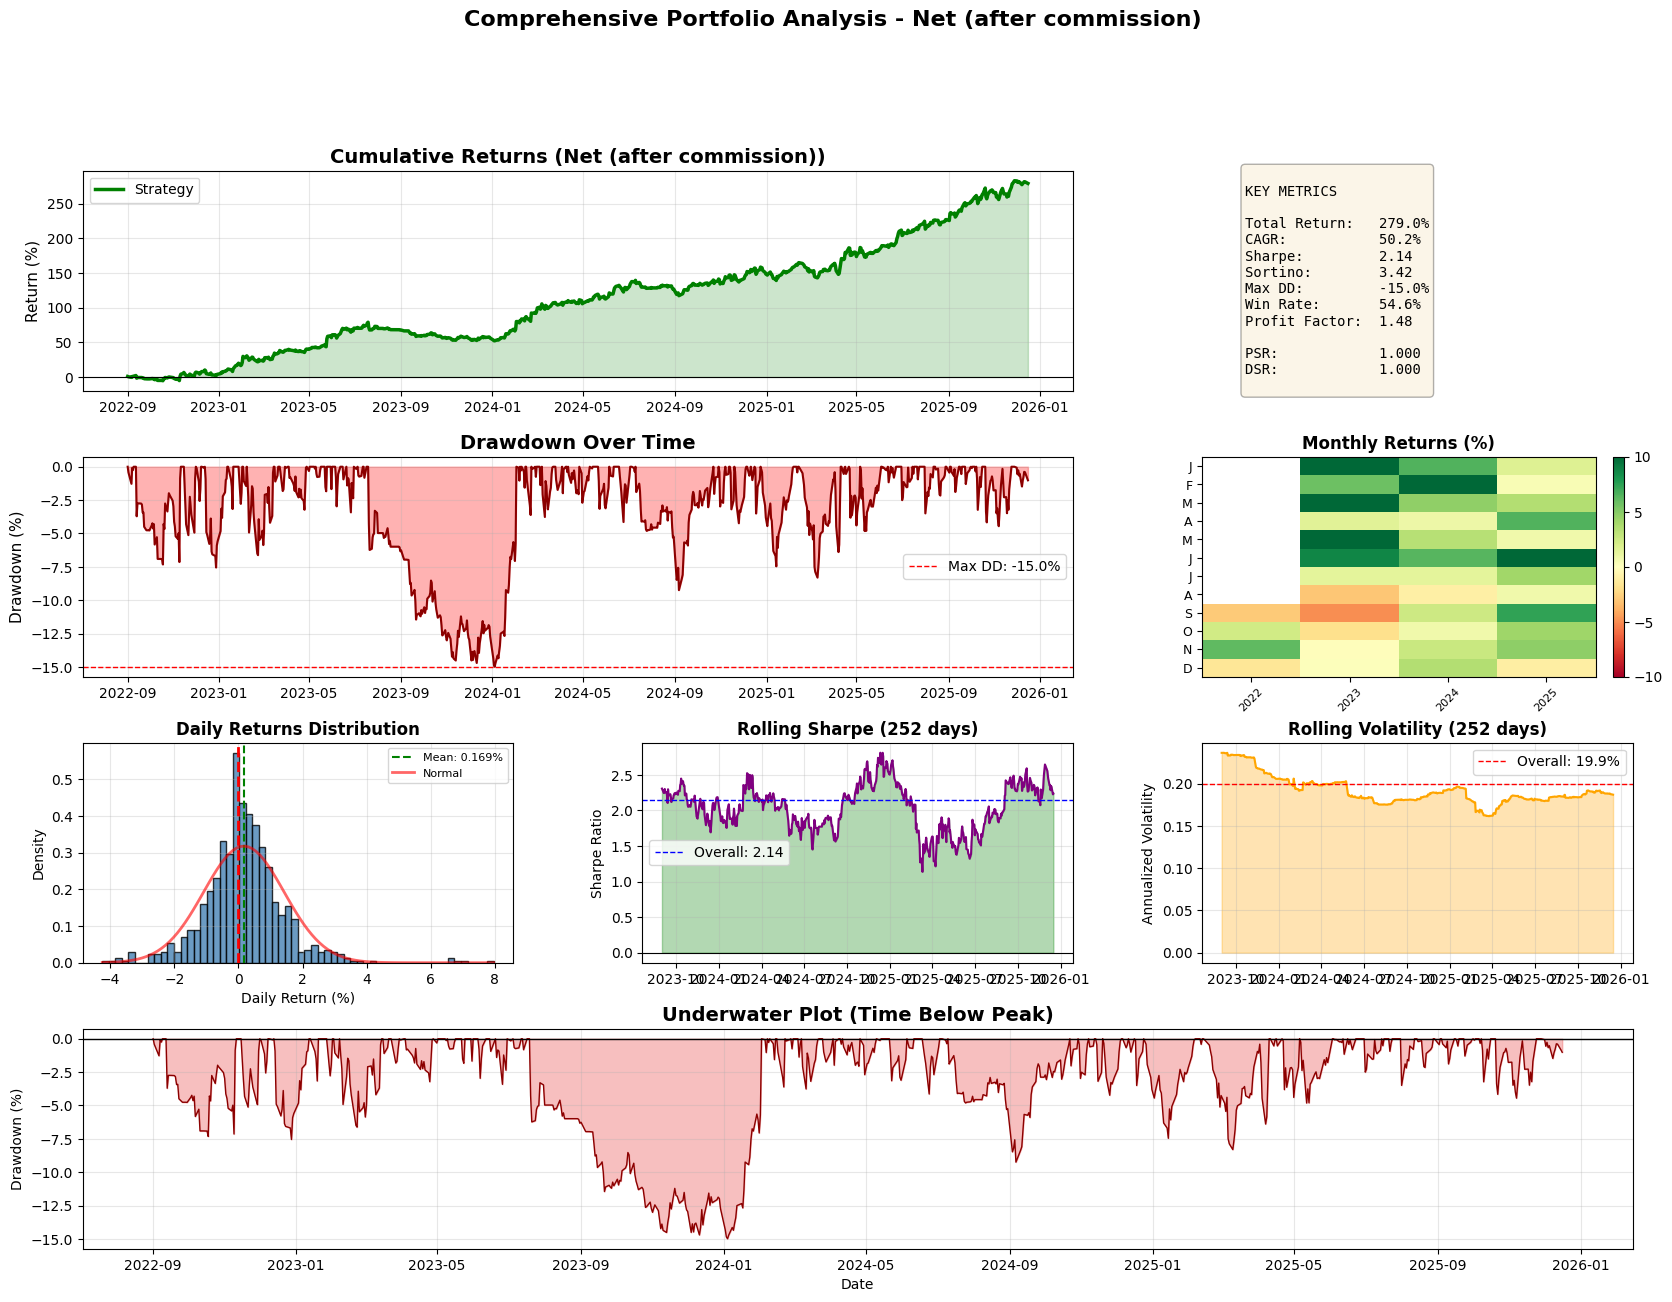

✅ STEP 5 COMPLETE - ALL CALCULATIONS VERIFIED


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# STEP 5: COMPREHENSIVE BACKTEST METRICS & VISUALS
# ============================================================

print("="*80)
print("STEP 5: COMPREHENSIVE BACKTEST METRICS & VISUALS")
print("="*80)

# ------------------------------------------------------------------
# 0) SELETTORE DATA INTELLIGENTE (NON DISTRUTTIVO)
# ------------------------------------------------------------------

# --- MODIFICA QUI LA DATA DI INIZIO ---
# Opzioni: None (Tutto), '2020-03-01' (Mentore), '2022-09-01' (Validation)
START_DATE_ANALYSIS = '2022-09-01'

# 1. CREAZIONE BACKUP (Se non esiste già)
# Questo impedisce di perdere i dati vecchi quando si applica un filtro
if 'allocation_df_master' not in locals():
    allocation_df_master = allocation_df.copy()
    print("💾 Backup creato: 'allocation_df_master' salvato in memoria.")
else:
    # Se il backup esiste, resettiamo allocation_df alla versione completa prima di filtrare
    allocation_df = allocation_df_master.copy()
    print("♻️  Dati ripristinati dal Backup Master (Full History).")

# 2. APPLICAZIONE FILTRO
if START_DATE_ANALYSIS is not None:
    try:
        print(f"✂️ FILTRO ATTIVO: Analisi limitata dal {START_DATE_ANALYSIS} in poi.")
        # Verifica validità data
        start_dt = pd.to_datetime(START_DATE_ANALYSIS)
        if start_dt > allocation_df.index[-1]:
            print("⚠️ ATTENZIONE: La data scelta è nel futuro! Ignoro il filtro.")
        elif start_dt < allocation_df.index[0]:
             print("⚠️ ATTENZIONE: La data scelta è precedente all'inizio dati. Uso tutto.")
        else:
            allocation_df = allocation_df.loc[START_DATE_ANALYSIS:].copy()
            print(f"✅ Nuova durata analisi: {len(allocation_df)} giorni di trading.")
    except Exception as e:
        print(f"⚠️ Errore nel filtro data: {e}. Uso tutto lo storico.")
else:
    print("🌍 ANALISI SU TUTTO LO STORICO DISPONIBILE (Full Sample).")


# ------------------------------------------------------------------
# CALCOLO RITORNI NETTI E METRICHE (CODICE ORIGINALE)
# ------------------------------------------------------------------
COMMISSION_RATE = 0.001  # 0.1% per trade side (approx. spread + comms)
weight_cols = [f'{t}_Weight' for t in tickers]

# Calcola i ritorni netti se non esistono già
if 'Portfolio_Return_After_Commission' not in allocation_df.columns:
    returns_gross = allocation_df['Portfolio_Return'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
    commission_series = np.zeros(len(allocation_df))
    
    if len(allocation_df) > 0:
        # Commissione iniziale
        first_w = allocation_df.iloc[0][weight_cols].values.astype(float)
        commission_series[0] = first_w.sum() * COMMISSION_RATE
        
        # Commissioni di ribilanciamento (Turnover)
        for i in range(1, len(allocation_df)):
            prev_w = allocation_df.iloc[i-1][weight_cols].values.astype(float)
            curr_w = allocation_df.iloc[i][weight_cols].values.astype(float)
            turnover = np.abs(curr_w - prev_w).sum() / 2.0
            commission_series[i] = turnover * COMMISSION_RATE
    
    returns_net = returns_gross - commission_series
    allocation_df['Commission'] = commission_series
    allocation_df['Portfolio_Return_After_Commission'] = returns_net

    total_commission_cost = commission_series.sum()
    print(f"\n💰 Commission Analysis:")
    print(f"  Commission rate:           {COMMISSION_RATE:.3%} per side ({COMMISSION_RATE*2:.3%} roundtrip)")
    print(f"  Total commissions paid:    {total_commission_cost:.4%} of initial capital")
    print(f"  Number of rebalances:      {len(allocation_history)}")
    if len(allocation_history) > 0:
         print(f"  Avg commission per trade: {total_commission_cost/len(allocation_history):.6%}")
    else:
         print("  Avg commission: N/A")

# Use NET returns
if 'Portfolio_Return_After_Commission' in allocation_df.columns:
    returns = allocation_df['Portfolio_Return_After_Commission'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
    label = 'Net (after commission)'
else:
    returns = allocation_df['Portfolio_Return'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
    label = 'Gross'

# ------------------------------------------------------------------
# 1) Portfolio value & basic stats
# ------------------------------------------------------------------
portfolio_value = (1 + returns).cumprod()
total_days = len(returns)
years = total_days / 252.0

# ------------------------------------------------------------------
# 2) Return metrics (VERIFIED)
# ------------------------------------------------------------------
# Total return = final portfolio value - 1 (starts at 1)
total_return = float(portfolio_value.iloc[-1] - 1)

# CAGR = geometric mean return annualized
cagr = float((portfolio_value.iloc[-1] ** (1/years) - 1)) if years > 0 else 0.0

# Annualized mean (arithmetic average of daily returns * 252)
mean_daily = float(returns.mean())
annualized_mean = mean_daily * 252

# Volatility (std of daily returns * sqrt(252))
std_daily = float(returns.std())
annual_volatility = std_daily * np.sqrt(252)

# ------------------------------------------------------------------
# 3) Risk-adjusted metrics (VERIFIED)
# ------------------------------------------------------------------
# Sharpe = annualized mean return / annualized volatility
sharpe_ratio = annualized_mean / annual_volatility if annual_volatility > 0 else 0.0

# Sortino = annualized mean return / downside deviation
downside = returns[returns < 0]
downside_std = float(downside.std() * np.sqrt(252)) if len(downside) > 1 else 0.0
sortino_ratio = annualized_mean / downside_std if downside_std > 0 else 0.0

# Max Drawdown (VERIFIED: portfolio_value / running_max - 1)
running_max = portfolio_value.cummax()
drawdown = (portfolio_value / running_max) - 1
max_drawdown = float(drawdown.min())

# Calmar = CAGR / |Max Drawdown|
calmar_ratio = cagr / abs(max_drawdown) if max_drawdown != 0 else 0.0

# Omega = sum(gains) / sum(|losses|) with threshold = 0
gains = float(returns[returns > 0].sum())
losses = float(abs(returns[returns < 0].sum()))
omega_ratio = gains / losses if losses > 0 else np.inf

# Information Ratio (against 0% benchmark = Sharpe Ratio)
tracking_error = annual_volatility
information_ratio = sharpe_ratio

# ------------------------------------------------------------------
# 4) Extended trading metrics (VERIFIED)
# ------------------------------------------------------------------
winning_days = int((returns > 0).sum())
losing_days = int((returns < 0).sum())
flat_days = int((returns == 0).sum())
win_rate = winning_days / total_days if total_days > 0 else 0.0
loss_rate = losing_days / total_days if total_days > 0 else 0.0

avg_win = float(returns[returns > 0].mean()) if winning_days > 0 else 0.0
avg_loss = float(returns[returns < 0].mean()) if losing_days > 0 else 0.0
win_loss_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else 0.0

max_win = float(returns.max())
max_loss = float(returns.min())

total_wins = gains  # already calculated above
total_losses = losses  # already calculated above
profit_factor = total_wins / total_losses if total_losses > 0 else 0.0

# Consecutive wins/losses
def max_consecutive(condition):
    if len(condition) == 0:
        return 0
    count = 0
    max_count = 0
    for val in condition:
        if val:
            count += 1
            max_count = max(max_count, count)
        else:
            count = 0
    return max_count

max_consecutive_wins = max_consecutive(returns > 0)
max_consecutive_losses = max_consecutive(returns < 0)

# Recovery factor = CAGR / |Max Drawdown|
recovery_factor = cagr / abs(max_drawdown) if max_drawdown != 0 else np.inf

# Ulcer Index = sqrt(mean of squared drawdowns)
squared_drawdowns = float((drawdown ** 2).mean())
ulcer_index = np.sqrt(squared_drawdowns)

# ------------------------------------------------------------------
# 5) Drawdown analysis (VERIFIED)
# ------------------------------------------------------------------
in_drawdown = drawdown < -0.01
dd_starts = []
dd_ends = []
dd_depths = []
dd_durations = []

i = 0
while i < len(drawdown):
    if in_drawdown.iloc[i]:
        start = i
        depth = drawdown.iloc[i]
        while i < len(drawdown) and in_drawdown.iloc[i]:
            depth = min(depth, drawdown.iloc[i])
            i += 1
        end = i - 1
        dd_starts.append(drawdown.index[start])
        dd_ends.append(drawdown.index[end])
        dd_depths.append(float(depth))
        dd_durations.append(end - start + 1)
    i += 1

avg_drawdown = float(np.mean(dd_depths)) if dd_depths else 0.0
avg_dd_duration = float(np.mean(dd_durations)) if dd_durations else 0.0
max_dd_duration = int(max(dd_durations)) if dd_durations else 0

# ------------------------------------------------------------------
# 6) Probabilistic Sharpe Ratio (Bailey & López de Prado, 2014)
# ------------------------------------------------------------------
try:
    skew = float(returns.skew())
    kurt = float(returns.kurtosis())  # excess kurtosis
    T = total_days

    # Standard error of Sharpe Ratio with higher moments
    sr_var_numerator = 1.0 + 0.5 * sharpe_ratio**2 - skew * sharpe_ratio + ((kurt - 1) / 4.0) * (sharpe_ratio ** 2)
    sr_var_numerator = max(sr_var_numerator, 0.01)
    sr_variance = sr_var_numerator / max(T - 1, 1)
    sr_std_error = float(np.sqrt(sr_variance))

    # PSR: probability that true Sharpe > 0
    sr_benchmark = 0.0  
    z_score = (sharpe_ratio - sr_benchmark) / sr_std_error if sr_std_error > 0 else 0.0
    psr = float(stats.norm.cdf(z_score))

    # Deflated Sharpe Ratio (accounts for multiple testing)
    # N_TRIALS: Set to number of distinct strategy configurations tested
    # 100 is a realistic number for manual/grid search optimization
    N_TRIALS = 100 

    if N_TRIALS > 1:
        # Expected maximum Sharpe from N independent trials
        expected_max_z = np.sqrt(2 * np.log(N_TRIALS)) - (
            (np.log(np.log(N_TRIALS)) + np.log(4*np.pi)) / (2 * np.sqrt(2 * np.log(N_TRIALS)))
        )
        sr_benchmark_deflated = expected_max_z * sr_std_error
        z_score_deflated = (sharpe_ratio - sr_benchmark_deflated) / sr_std_error if sr_std_error > 0 else 0.0
        dsr = float(stats.norm.cdf(z_score_deflated))
    else:
        dsr = psr

    # Probabilistic Sortino
    if downside_std > 0:
        sortino_var_numerator = 1.0 + 0.5 * sortino_ratio**2 - skew * sortino_ratio + ((kurt - 1) / 4.0) * (sortino_ratio ** 2)
        sortino_var_numerator = max(sortino_var_numerator, 0.01)
        sortino_variance = sortino_var_numerator / max(T - 1, 1)
        sortino_std_error = float(np.sqrt(sortino_variance))
        z_sortino = (sortino_ratio - 0.0) / sortino_std_error if sortino_std_error > 0 else 0.0
        prob_sortino = float(stats.norm.cdf(z_sortino))
    else:
        prob_sortino = 0.0

except Exception as e:
    psr, dsr, prob_sortino = 0.0, 0.0, 0.0
    sr_std_error = 0.0
    print(f"⚠️  Warning: PSR calculation failed: {e}")

# ------------------------------------------------------------------
# 6b) Verification of PSR calculation
# ------------------------------------------------------------------
print("🔍 PSR VERIFICATION:")
print(f"  Annualized Sharpe:         {sharpe_ratio:.4f}")
print(f"  Sharpe Std Error:          {sr_std_error:.4f}")
print(f"  Skewness:                  {skew:.4f}")
print(f"  Excess Kurtosis:           {kurt:.4f}")
print(f"  Sample Size (T):           {T}")
print(f"  N_trials:                  {N_TRIALS}")
print(f"  Z-score vs 0:              {z_score:.4f}")
print(f"  PSR:                       {psr:.4f}")
print(f"  DSR:                       {dsr:.4f}")
print()

# ------------------------------------------------------------------
# 7) Rolling metrics (VERIFIED)
# ------------------------------------------------------------------
window = 252
rolling_mean = returns.rolling(window).mean() * 252
rolling_std = returns.rolling(window).std() * np.sqrt(252)
rolling_sharpe = rolling_mean / rolling_std

# ------------------------------------------------------------------
# 8) Print comprehensive results
# ------------------------------------------------------------------
print(f"\n{'='*80}")
print(f"USING RETURNS: {label.upper()}")
print(f"Period: {total_days} days ({years:.2f} years)")
print(f"{'='*80}\n")

print("📊 RETURN METRICS")
print(f"  Total Return:              {total_return:>12.2%}")
print(f"  CAGR (geometric):          {cagr:>12.2%}")
print(f"  Annualized Mean Return:    {annualized_mean:>12.2%}")
print(f"  Annualized Volatility:     {annual_volatility:>12.2%}")
print()

print("📈 RISK-ADJUSTED METRICS")
print(f"  Sharpe Ratio:              {sharpe_ratio:>12.3f}")
print(f"  Sortino Ratio:             {sortino_ratio:>12.3f}")
print(f"  Calmar Ratio:              {calmar_ratio:>12.3f}")
print(f"  Information Ratio:         {information_ratio:>12.3f}")
print(f"  Omega Ratio:               {omega_ratio:>12.3f}")
print()

print("📉 DRAWDOWN METRICS")
print(f"  Max Drawdown:              {max_drawdown:>12.2%}")
print(f"  Avg Drawdown:              {avg_drawdown:>12.2%}")
print(f"  Max DD Duration:           {max_dd_duration:>12.0f} days")
print(f"  Avg DD Duration:           {avg_dd_duration:>12.1f} days")
print(f"  Ulcer Index:               {ulcer_index:>12.4f}")
print(f"  Recovery Factor:           {recovery_factor:>12.2f}")
print()

print("🎯 PROBABILISTIC METRICS (Bailey & López de Prado)")
print(f"  Prob. Sharpe Ratio (PSR): {psr:>12.3f}")
print(f"  Deflated Sharpe (DSR):     {dsr:>12.3f}  [N_trials={N_TRIALS}]")
print(f"  Prob. Sortino:             {prob_sortino:>12.3f}")
print(f"  (PSR = probability true SR > 0)")
print()

print("💰 TRADING METRICS")
print(f"  Win Rate:                  {win_rate:>12.2%}")
print(f"  Loss Rate:                 {loss_rate:>12.2%}")
print(f"  Avg Win:                   {avg_win:>12.4%}")
print(f"  Avg Loss:                  {avg_loss:>12.4%}")
print(f"  Best Day:                  {max_win:>12.4%}")
print(f"  Worst Day:                 {max_loss:>12.4%}")
print(f"  Win/Loss Ratio:            {win_loss_ratio:>12.2f}")
print(f"  Profit Factor:             {profit_factor:>12.2f}")
print(f"  Max Consecutive Wins:      {max_consecutive_wins:>12.0f}")
print(f"  Max Consecutive Losses:    {max_consecutive_losses:>12.0f}")
print()

print("🔍 VERIFICATION CHECKS")
print(f"  Mean daily return:         {mean_daily:>12.6%}")
print(f"  Std daily return:          {std_daily:>12.6%}")
print(f"  Daily Sharpe:              {mean_daily/std_daily if std_daily > 0 else 0:>12.3f}")
print(f"  Skewness:                  {skew:>12.3f}")
print(f"  Excess Kurtosis:           {kurt:>12.3f}")
print(f"  Sharpe Std Error:          {sr_std_error:>12.4f}")
print(f"  Commission Rate:           {COMMISSION_RATE:>12.3%} per side")
print()

# Additional verification calculations
print("📋 CROSS-VERIFICATION:")
print(f"  Total return check:        {(1 + total_return):.6f} (should = portfolio_value[-1])")
print(f"  CAGR check:                {((1 + total_return) ** (1/years) - 1):.6f} (should ≈ CAGR)")
print(f"  Annualized mean check:     {mean_daily * 252:.6f} (should = annualized_mean)")
print(f"  Volatility check:          {std_daily * np.sqrt(252):.6f} (should = annual_volatility)")
print(f"  Sharpe check:              {annualized_mean / annual_volatility:.6f} (should = sharpe_ratio)")
print(f"  Sortino check:             {annualized_mean / downside_std:.6f} (should = sortino_ratio)")
print(f"  Max DD check:              {drawdown.min():.6f} (should = max_drawdown)")
print(f"  Calmar check:              {cagr / abs(max_drawdown):.6f} (should = calmar_ratio)")
print()

print("📊 PSR VERIFICATION:")
print(f"  Formula used:              SE(SR) = sqrt((1 + 0.5*SR² - skew*SR + ((kurt-1)/4)*SR²) / (T-1))")
print(f"  SR variance numerator:     {1 + 0.5 * sharpe_ratio**2 - skew * sharpe_ratio + ((kurt - 1) / 4.0) * (sharpe_ratio ** 2):.6f}")
print(f"  Degrees of freedom:        {max(T - 1, 1)}")
print(f"  Expected result:           PSR < 1.0 unless SR is extremely high relative to its uncertainty")
print()

# ------------------------------------------------------------------
# 9) COMPREHENSIVE VISUALIZATIONS
# ------------------------------------------------------------------
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1) Cumulative Returns
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(portfolio_value.index, (portfolio_value - 1) * 100, lw=2.5, color='green', label='Strategy')
ax1.fill_between(portfolio_value.index, 0, (portfolio_value - 1) * 100, alpha=0.2, color='green')
ax1.set_title(f'Cumulative Returns ({label})', fontsize=14, fontweight='bold')
ax1.set_ylabel('Return (%)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', lw=0.8)
ax1.legend(loc='upper left')

# 2) Key Metrics Box
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
metrics_text = f"""
KEY METRICS

Total Return:   {total_return:.1%}
CAGR:           {cagr:.1%}
Sharpe:         {sharpe_ratio:.2f}
Sortino:        {sortino_ratio:.2f}
Max DD:         {max_drawdown:.1%}
Win Rate:       {win_rate:.1%}
Profit Factor:  {profit_factor:.2f}

PSR:            {psr:.3f}
DSR:            {dsr:.3f}
"""
ax2.text(0.1, 0.5, metrics_text, fontsize=10, family='monospace', 
          verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# 3) Drawdown
ax3 = fig.add_subplot(gs[1, :2])
ax3.fill_between(drawdown.index, drawdown.values * 100, 0, color='red', alpha=0.3)
ax3.plot(drawdown.index, drawdown.values * 100, color='darkred', lw=1.5)
ax3.set_title('Drawdown Over Time', fontsize=14, fontweight='bold')
ax3.set_ylabel('Drawdown (%)', fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=max_drawdown*100, color='red', ls='--', lw=1, label=f'Max DD: {max_drawdown:.1%}')
ax3.legend()

# 4) Monthly Returns Heatmap
ax4 = fig.add_subplot(gs[1, 2])
try:
    if not isinstance(returns.index, pd.DatetimeIndex):
        returns_with_dt = returns.copy()
        returns_with_dt.index = pd.to_datetime(returns.index)
    else:
        returns_with_dt = returns
    
    monthly_returns = returns_with_dt.resample('M').apply(lambda x: (1 + x).prod() - 1)
    years_unique = monthly_returns.index.year.unique()
    
    matrix = np.full((12, len(years_unique)), np.nan)
    for i, ret in enumerate(monthly_returns):
        year_idx = np.where(years_unique == monthly_returns.index[i].year)[0][0]
        month_idx = monthly_returns.index[i].month - 1
        matrix[month_idx, year_idx] = ret * 100
    
    
    im = ax4.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=10)
    ax4.set_yticks(range(12))
    ax4.set_yticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'], fontsize=9)
    ax4.set_xticks(range(len(years_unique)))
    ax4.set_xticklabels(years_unique, rotation=45, fontsize=8)
    ax4.set_title('Monthly Returns (%)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
except Exception as e:
    ax4.text(0.5, 0.5, 'Monthly heatmap\nunavailable', 
              ha='center', va='center', transform=ax4.transAxes, fontsize=10)
    ax4.set_title('Monthly Returns', fontsize=12, fontweight='bold')

# 5) Daily Returns Distribution
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(returns * 100, bins=60, color='steelblue', edgecolor='black', alpha=0.8, density=True)
ax5.axvline(0, color='red', ls='--', lw=2)
ax5.axvline(mean_daily*100, color='green', ls='--', lw=1.5, label=f'Mean: {mean_daily:.3%}')
mu, sigma = mean_daily * 100, std_daily * 100
x = np.linspace(returns.min()*100, returns.max()*100, 100)
ax5.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, alpha=0.6, label='Normal')
ax5.set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
ax5.set_xlabel('Daily Return (%)')
ax5.set_ylabel('Density')
ax5.grid(True, alpha=0.3)
ax5.legend(fontsize=8)

# 6) Rolling Sharpe
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(rolling_sharpe.index, rolling_sharpe.values, color='purple', lw=1.5)
ax6.fill_between(rolling_sharpe.index, 0, rolling_sharpe.values, where=(rolling_sharpe.values > 0), 
                  color='green', alpha=0.3, interpolate=True)
ax6.fill_between(rolling_sharpe.index, 0, rolling_sharpe.values, where=(rolling_sharpe.values <= 0), 
                  color='red', alpha=0.3, interpolate=True)
ax6.set_title(f'Rolling Sharpe ({window} days)', fontsize=12, fontweight='bold')
ax6.set_ylabel('Sharpe Ratio')
ax6.grid(True, alpha=0.3)
ax6.axhline(0, color='black', lw=0.8)
ax6.axhline(sharpe_ratio, color='blue', ls='--', lw=1, label=f'Overall: {sharpe_ratio:.2f}')
ax6.legend()

# 7) Rolling Volatility
ax7 = fig.add_subplot(gs[2, 2])
ax7.plot(rolling_std.index, rolling_std.values, color='orange', lw=1.5)
ax7.fill_between(rolling_std.index, 0, rolling_std.values, color='orange', alpha=0.3)
ax7.set_title(f'Rolling Volatility ({window} days)', fontsize=12, fontweight='bold')
ax7.set_ylabel('Annualized Volatility')
ax7.grid(True, alpha=0.3)
ax7.axhline(annual_volatility, color='red', ls='--', lw=1, label=f'Overall: {annual_volatility:.1%}')
ax7.legend()

# 8) Underwater Plot
ax8 = fig.add_subplot(gs[3, :])
ax8.fill_between(drawdown.index, drawdown.values * 100, 0, alpha=0.5, color='lightcoral')
ax8.plot(drawdown.index, drawdown.values * 100, color='darkred', lw=1)
ax8.set_title('Underwater Plot (Time Below Peak)', fontsize=14, fontweight='bold')
ax8.set_ylabel('Drawdown (%)')
ax8.set_xlabel('Date')
ax8.grid(True, alpha=0.3)
ax8.axhline(y=0, color='black', lw=1)

plt.suptitle(f'Comprehensive Portfolio Analysis - {label}', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("="*80)
print("✅ STEP 5 COMPLETE - ALL CALCULATIONS VERIFIED")
print("="*80)

BUY & HOLD BENCHMARK: ZERO SWAP COST ANALYSIS


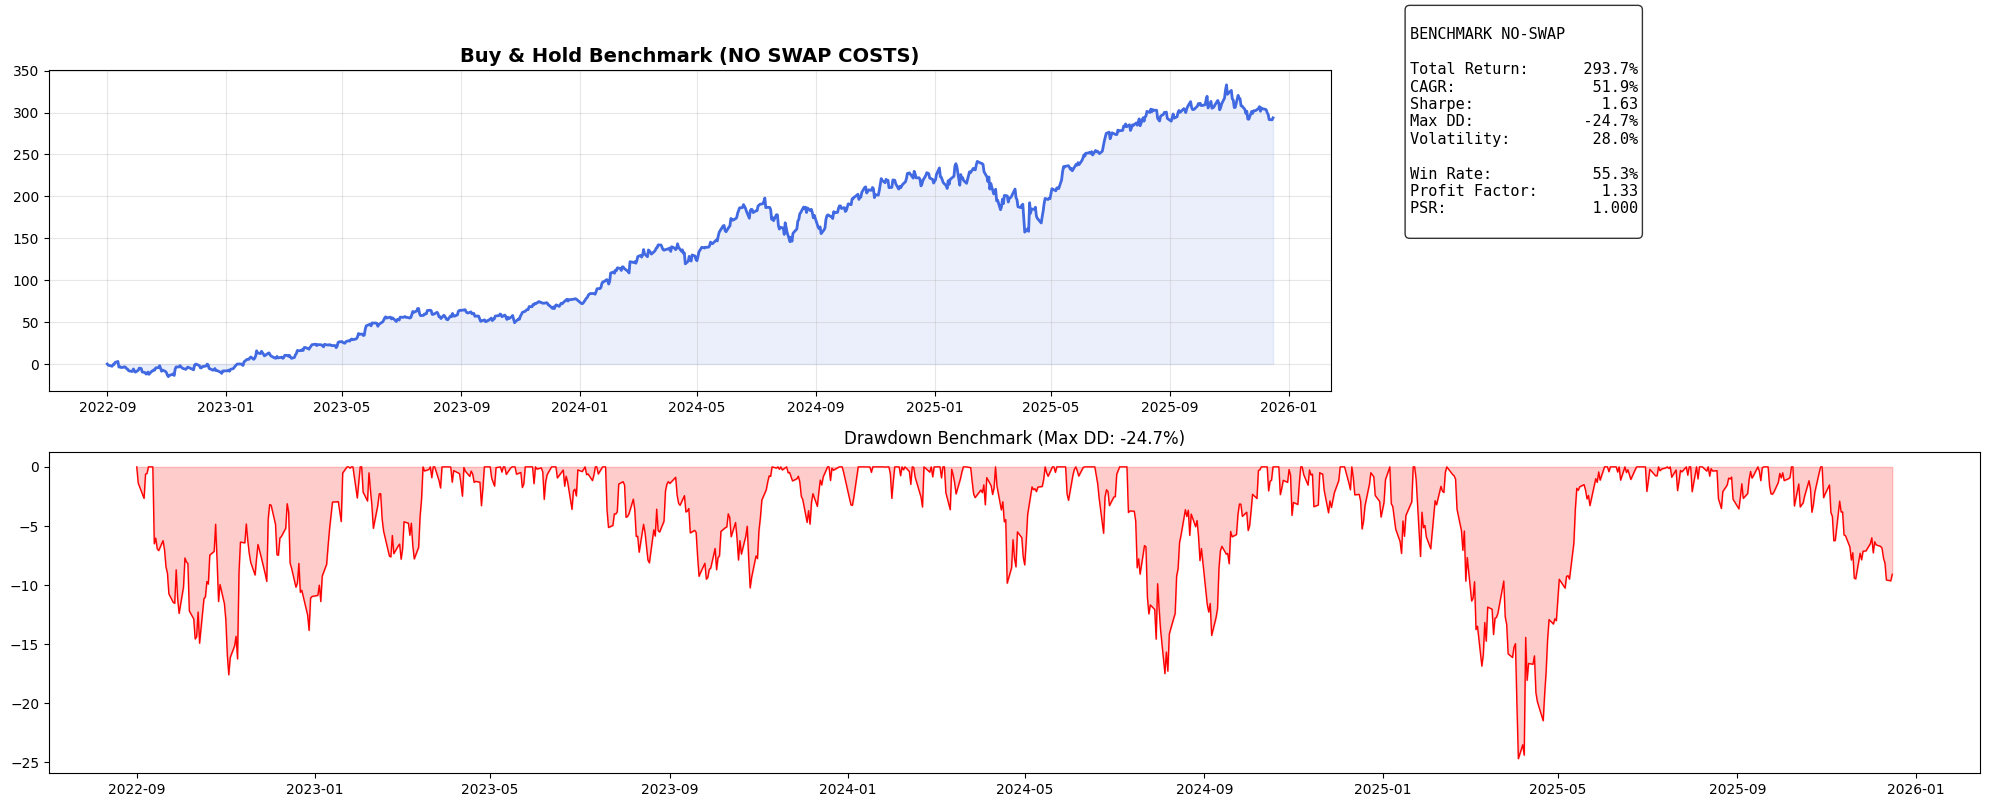

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print("="*80)
print("BUY & HOLD BENCHMARK: ZERO SWAP COST ANALYSIS")
print("="*80)

# 1. SETUP
INITIAL_CAPITAL = 100000 
bh_tickers = ['AAPL', 'AMZN', 'GC=F', 'GOOG', 'META', 'MSFT', 'NFLX', 'NVDA']

bh_df = combined_df.loc[allocation_df.index].copy()
budget_per_asset = INITIAL_CAPITAL / len(bh_tickers)
units_held = {}
current_cash = INITIAL_CAPITAL

# FASE A: ACQUISTO INIZIALE (Solo Commissioni, NO Swap)
first_idx = bh_df.index[0]
for t in bh_tickers:
    price = bh_df.loc[first_idx, f'{t}_Close']
    # Arrotondamento lotti/unità
    if t == 'GC=F':
        units = (budget_per_asset / price) // (0.01 * 100) * (0.01 * 100)
    else:
        units = budget_per_asset // price
    
    units_held[t] = units
    # Commissione d'ingresso (0.002% azioni | 0.0007% oro)
    comm = (units * price) * (0.000007 if t == 'GC=F' else 0.00002)
    current_cash -= (units * price) + comm

# FASE B: SIMULAZIONE EQUITY (SENZA ADDEBITO SWAP)
equity_series = []
for i in range(len(bh_df)):
    idx = bh_df.index[i]
    market_value = sum(units_held[t] * bh_df.loc[idx, f'{t}_Close'] for t in bh_tickers)
    # L'Equity è solo Valore Titoli + Cash (che non viene più eroso dagli swap)
    equity_series.append(market_value + current_cash)

# FASE C: CALCOLO METRICHE AVANZATE
portfolio_value = pd.Series(equity_series, index=bh_df.index)
returns = portfolio_value.pct_change().fillna(0)

total_days = len(returns)
years = total_days / 252
total_return = (portfolio_value.iloc[-1] / INITIAL_CAPITAL) - 1
cagr = (portfolio_value.iloc[-1] / INITIAL_CAPITAL) ** (1/years) - 1
ann_mean = returns.mean() * 252
ann_vol = returns.std() * np.sqrt(252)
sharpe = ann_mean / ann_vol if ann_vol > 0 else 0

running_max = portfolio_value.cummax()
drawdown = (portfolio_value / running_max) - 1
max_drawdown = float(drawdown.min())

# Metriche Trading
win_rate = (returns > 0).sum() / total_days
gains = returns[returns > 0].sum()
losses = abs(returns[returns < 0].sum())
profit_factor = gains / losses if losses > 0 else 0

# Probabilistic Sharpe Ratio (PSR)
skew = returns.skew()
kurt = returns.kurtosis()
sr_std_error = np.sqrt((1 + 0.5 * sharpe**2 - skew * sharpe + (kurt/4) * sharpe**2) / (total_days - 1))
psr = stats.norm.cdf(sharpe / sr_std_error) if sr_std_error > 0 else 0

# ------------------------------------------------------------------
# VISUALIZZAZIONE
# ------------------------------------------------------------------
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3)

# 1. Equity Curve
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(portfolio_value.index, (portfolio_value / INITIAL_CAPITAL - 1) * 100, color='royalblue', lw=2)
ax1.fill_between(portfolio_value.index, 0, (portfolio_value / INITIAL_CAPITAL - 1) * 100, alpha=0.1, color='royalblue')
ax1.set_title('Buy & Hold Benchmark (NO SWAP COSTS)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Box Metriche
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
metrics_text = f"""
BENCHMARK NO-SWAP

Total Return:  {total_return:>10.1%}
CAGR:          {cagr:>10.1%}
Sharpe:        {sharpe:>10.2f}
Max DD:        {max_drawdown:>10.1%}
Volatility:    {ann_vol:>10.1%}

Win Rate:      {win_rate:>10.1%}
Profit Factor: {profit_factor:>10.2f}
PSR:           {psr:>10.3f}
"""
ax2.text(0.1, 0.5, metrics_text, fontsize=11, family='monospace', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Drawdown Plot
ax3 = fig.add_subplot(gs[1, :])
ax3.fill_between(drawdown.index, drawdown.values * 100, 0, color='red', alpha=0.2)
ax3.plot(drawdown.index, drawdown.values * 100, color='red', lw=1)
ax3.set_title(f'Drawdown Benchmark (Max DD: {max_drawdown:.1%})', fontsize=12)

plt.tight_layout()
plt.show()

REPORT EFFICIENZA ALLOCAZIONE (MT5 COMPLIANCE)
1. Giorni con Mismatch (Size non raggiunta): 1730 su 1998
2. Cash Drag Medio (Senza Ottimizzazione):  169.20€ per giorno
3. Esposizione Media Persa (Finale):        0.9370%
4. Interventi Oro come 'Serbatoio':         138 giorni
5. Giorni in cui l'Oro era 'Spento':        1169 giorni


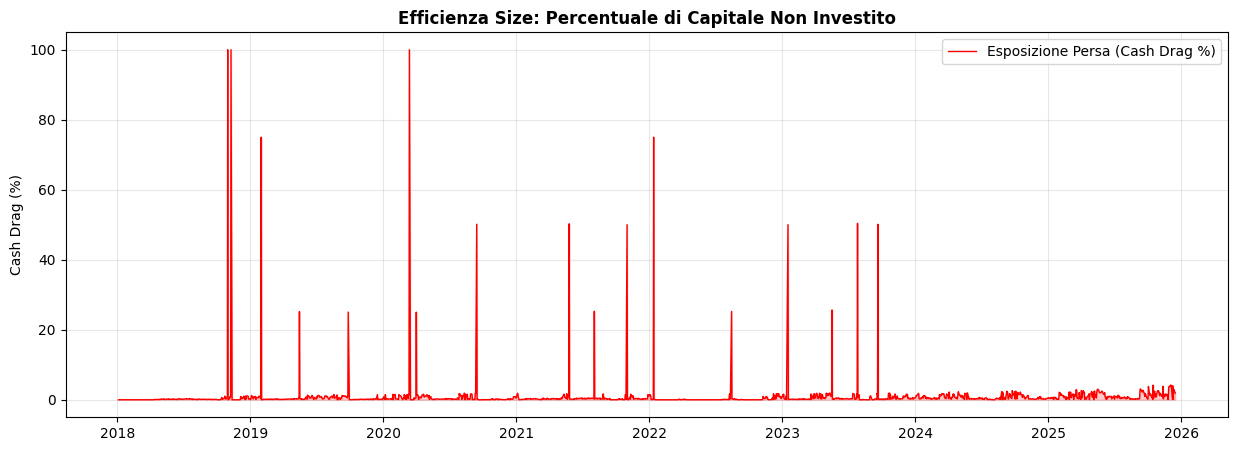

In [22]:
# ============================================================
# ANALISI EFFICIENZA SIZE E OTTIMIZZAZIONE ORO (GC=F)
# ============================================================

efficiency_data = []
capital_for_analysis = INITIAL_CAPITAL

for i in range(len(allocation_df)):
    idx = allocation_df.index[i]
    
    # 1. Recupero Pesi Teorici (Target)
    target_weights = {t: allocation_df.loc[idx, f'{t}_Weight'] for t in tickers if allocation_df.loc[idx, f'{t}_Weight'] > 0.001}
    target_exposure = sum(target_weights.values())
    
    # 2. Calcolo Unità Reali e Leftover (Logica Stock)
    leftover_cash = 0
    actual_stock_value = 0
    for t, w in target_weights.items():
        if t == 'GC=F': continue
        price = combined_df.loc[idx, f'{t}_Close']
        units = (capital_for_analysis * w) // price # Lotto intero
        actual_stock_value += (units * price)
        leftover_cash += ((capital_for_analysis * w) - (units * price))
        
    # 3. Gestione Oro (Riempimento)
    gold_status = "NOT_LONG"
    actual_gold_value = 0
    w_gold_target = target_weights.get('GC=F', 0)
    
    gold_pos = combined_df.loc[idx, 'GC=F_Position']
    gold_rank = combined_df.loc[idx, 'GC=F_Rank']
    
    if gold_pos == 1 and gold_rank > 0:
        gold_status = "FILLING" if w_gold_target == 0 else "ACTIVE_ROTATION"
        price_gold = combined_df.loc[idx, 'GC=F_Close']
        target_val_gold = (capital_for_analysis * w_gold_target) + leftover_cash
        # Step 0.01 lotti (1 oncia)
        units_gold = (target_val_gold / price_gold) // (0.01 * 100) * (0.01 * 100)
        actual_gold_value = units_gold * price_gold
    
    # 4. Risultato Finale Giornata
    total_actual_invested = actual_stock_value + actual_gold_value
    actual_exposure = total_actual_invested / capital_for_analysis
    cash_drag = target_exposure - actual_exposure
    
    efficiency_data.append({
        'Date': idx,
        'Target_Exposure': target_exposure,
        'Actual_Exposure': actual_exposure,
        'Cash_Drag': cash_drag,
        'Gold_Status': gold_status,
        'Leftover_From_Stocks': leftover_cash
    })

eff_df = pd.DataFrame(efficiency_data).set_index('Date')

# --- STATISTICHE DI SINTESI ---
print("="*80)
print("REPORT EFFICIENZA ALLOCAZIONE (MT5 COMPLIANCE)")
print("="*80)
print(f"1. Giorni con Mismatch (Size non raggiunta): {(eff_df['Cash_Drag'] > 0.0001).sum()} su {len(eff_df)}")
print(f"2. Cash Drag Medio (Senza Ottimizzazione):  {eff_df['Leftover_From_Stocks'].mean():.2f}€ per giorno")
print(f"3. Esposizione Media Persa (Finale):        {eff_df['Cash_Drag'].mean():.4%}")
print(f"4. Interventi Oro come 'Serbatoio':         {(eff_df['Gold_Status'] == 'FILLING').sum()} giorni")
print(f"5. Giorni in cui l'Oro era 'Spento':        {(eff_df['Gold_Status'] == 'NOT_LONG').sum()} giorni")

# --- VISUALIZZAZIONE ---
plt.figure(figsize=(15, 5))
plt.plot(eff_df.index, eff_df['Cash_Drag'] * 100, color='red', lw=1, label='Esposizione Persa (Cash Drag %)')
plt.fill_between(eff_df.index, 0, eff_df['Cash_Drag'] * 100, color='red', alpha=0.2)
plt.title('Efficienza Size: Percentuale di Capitale Non Investito', fontsize=12, fontweight='bold')
plt.ylabel('Cash Drag (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [24]:
import pandas as pd
import numpy as np

# ============================================================
# STEP 7 (Analytics): PER-ASSET, PER-YEAR DETAILED ANALYSIS
# ============================================================

print("="*80)
print("PER-ASSET, PER-YEAR DETAILED ANALYSIS")
print("="*80)

# 0. Preparazione Dati
if not isinstance(allocation_df.index, pd.DatetimeIndex):
    allocation_df_dt = allocation_df.copy()
    allocation_df_dt.index = pd.to_datetime(allocation_df.index)
else:
    allocation_df_dt = allocation_df

years_list = sorted(allocation_df_dt.index.year.unique())

# ------------------------------------------------------------------
# 1) ASSET PARTICIPATION BY YEAR (Giorni in portafoglio)
# ------------------------------------------------------------------
print("\n📊 ASSET PARTICIPATION BY YEAR (Days Held / % of Year)\n")

participation_data = []

for ticker in tickers:
    weight_col = f'{ticker}_Weight'
    if weight_col not in allocation_df_dt.columns: continue

    row_data = {'Asset': ticker}
    
    # Dati annuali
    for year in years_list:
        year_mask = allocation_df_dt.index.year == year
        year_weights = allocation_df_dt.loc[year_mask, weight_col]
        
        days_held = (year_weights > 0.001).sum()
        total_days = len(year_weights)
        pct_held = days_held / total_days * 100 if total_days > 0 else 0
        
        row_data[year] = f"{days_held} ({pct_held:.0f}%)"
    
    # Totale
    total_days_held = (allocation_df_dt[weight_col] > 0.001).sum()
    total_days = len(allocation_df_dt)
    total_pct = total_days_held / total_days * 100
    row_data['TOTAL'] = f"{total_days_held} ({total_pct:.0f}%)"
    
    participation_data.append(row_data)

participation_df = pd.DataFrame(participation_data)
print(participation_df.to_string(index=False))

# ------------------------------------------------------------------
# 2) AVERAGE WEIGHT PER ASSET PER YEAR (Esposizione Media)
# ------------------------------------------------------------------
print("\n\n📈 AVERAGE WEIGHT PER ASSET PER YEAR (% of Portfolio)\n")

weight_data = []

for ticker in tickers:
    weight_col = f'{ticker}_Weight'
    if weight_col not in allocation_df_dt.columns: continue

    row_data = {'Asset': ticker}
    
    for year in years_list:
        year_mask = allocation_df_dt.index.year == year
        year_weights = allocation_df_dt.loc[year_mask, weight_col]
        avg_weight = year_weights.mean() * 100
        row_data[year] = f"{avg_weight:.1f}%"
    
    total_avg = allocation_df_dt[weight_col].mean() * 100
    row_data['TOTAL'] = f"{total_avg:.1f}%"
    
    weight_data.append(row_data)

weight_df = pd.DataFrame(weight_data)
print(weight_df.to_string(index=False))

# ------------------------------------------------------------------
# 3) AVERAGE WEIGHT WHEN HELD (Size media quando si entra)
# ------------------------------------------------------------------
print("\n\n💼 AVERAGE WEIGHT WHEN HELD PER ASSET PER YEAR (% when position > 0)\n")

cond_weight_data = []

for ticker in tickers:
    weight_col = f'{ticker}_Weight'
    if weight_col not in allocation_df_dt.columns: continue

    row_data = {'Asset': ticker}
    
    for year in years_list:
        year_mask = allocation_df_dt.index.year == year
        year_weights = allocation_df_dt.loc[year_mask, weight_col]
        year_weights_held = year_weights[year_weights > 0.001]
        
        if len(year_weights_held) > 0:
            avg_weight_held = year_weights_held.mean() * 100
            row_data[year] = f"{avg_weight_held:.1f}%"
        else:
            row_data[year] = "-"
    
    total_weights_held = allocation_df_dt.loc[allocation_df_dt[weight_col] > 0.001, weight_col]
    if len(total_weights_held) > 0:
        total_avg_held = total_weights_held.mean() * 100
        row_data['TOTAL'] = f"{total_avg_held:.1f}%"
    else:
        row_data['TOTAL'] = "-"
    
    cond_weight_data.append(row_data)

cond_weight_df = pd.DataFrame(cond_weight_data)
print(cond_weight_df.to_string(index=False))

# ------------------------------------------------------------------
# 4) CONTRIBUTION TO PORTFOLIO RETURNS (Profitto generato)
# ------------------------------------------------------------------
print("\n\n💰 CONTRIBUTION TO PORTFOLIO RETURNS BY ASSET BY YEAR\n")

# Calcolo Vettoriale Preciso
contribution_df_calc = pd.DataFrame(index=allocation_df_dt.index)

# Recuperiamo i pesi shiftati (Ieri) e i ritorni (Oggi)
weights_shifted = allocation_df_dt[[c for c in allocation_df_dt.columns if '_Weight' in c]].shift(1)

for ticker in tickers:
    w_col = f'{ticker}_Weight'
    r_col = f'{ticker}_Return'
    
    if w_col in weights_shifted.columns and r_col in combined_df.columns:
        # Allineamento indici
        common_idx = weights_shifted.index.intersection(combined_df.index)
        w = weights_shifted.loc[common_idx, w_col]
        r = combined_df.loc[common_idx, r_col]
        
        # Contributo = Peso(t-1) * Ritorno(t)
        contribution_df_calc[ticker] = w * r

contribution_data = []

for ticker in tickers:
    if ticker not in contribution_df_calc.columns: continue
    
    row_data = {'Asset': ticker}
    ticker_contrib = contribution_df_calc[ticker].fillna(0)
    
    for year in years_list:
        year_mask = ticker_contrib.index.year == year
        year_sum = ticker_contrib[year_mask].sum()
        row_data[year] = f"{year_sum:.2%}"
        
    total_sum = ticker_contrib.sum()
    row_data['TOTAL'] = f"{total_sum:.2%}"
    
    contribution_data.append(row_data)

contribution_display_df = pd.DataFrame(contribution_data)
print(contribution_display_df.to_string(index=False))

# ------------------------------------------------------------------
# 5) MAX WEIGHT ACHIEVED
# ------------------------------------------------------------------
print("\n\n🎯 MAXIMUM WEIGHT ACHIEVED PER ASSET PER YEAR\n")

max_weight_data = []

for ticker in tickers:
    weight_col = f'{ticker}_Weight'
    if weight_col not in allocation_df_dt.columns: continue

    row_data = {'Asset': ticker}
    
    for year in years_list:
        year_mask = allocation_df_dt.index.year == year
        year_weights = allocation_df_dt.loc[year_mask, weight_col]
        max_w = year_weights.max() * 100
        row_data[year] = f"{max_w:.0f}%"
    
    total_max = allocation_df_dt[weight_col].max() * 100
    row_data['TOTAL'] = f"{total_max:.0f}%"
    
    max_weight_data.append(row_data)

max_weight_df = pd.DataFrame(max_weight_data)
print(max_weight_df.to_string(index=False))

# ------------------------------------------------------------------
# 6) SUMMARY INSIGHTS
# ------------------------------------------------------------------
print("\n\n📋 SUMMARY INSIGHTS:\n")

# Most held asset per year
print("Most Held Asset Per Year:")
for year in years_list:
    year_mask = allocation_df_dt.index.year == year
    # Calcolo veloce vettoriale
    year_data = allocation_df_dt[year_mask]
    
    best_ticker = "None"
    max_days = 0
    
    for ticker in tickers:
        w_col = f'{ticker}_Weight'
        if w_col in year_data.columns:
            d = (year_data[w_col] > 0.001).sum()
            if d > max_days:
                max_days = d
                best_ticker = ticker
    
    total_days = len(year_data)
    pct = max_days / total_days * 100 if total_days > 0 else 0
    print(f"  {year}: {best_ticker} ({max_days} days, {pct:.1f}%)")

# Safe haven usage
print(f"\nSafe Haven ({SAFE_HAVEN}) Usage Per Year:")
sh_col = f'{SAFE_HAVEN}_Weight'

if sh_col in allocation_df_dt.columns:
    for year in years_list:
        year_mask = allocation_df_dt.index.year == year
        sh_weights = allocation_df_dt.loc[year_mask, sh_col]
        
        days_used = (sh_weights > 0.001).sum()
        total_days = len(sh_weights)
        pct_used = days_used / total_days * 100 if total_days > 0 else 0
        
        held_weights = sh_weights[sh_weights > 0.001]
        avg_w = held_weights.mean() * 100 if len(held_weights) > 0 else 0
        
        print(f"  {year}: {days_used} days ({pct_used:.1f}%), avg weight: {avg_w:.1f}%")
else:
    print(f"  Safe Haven column {sh_col} not found.")

print("\n" + "="*80)
print("✅ PER-ASSET PER-YEAR ANALYSIS COMPLETE")
print("="*80)

PER-ASSET, PER-YEAR DETAILED ANALYSIS

📊 ASSET PARTICIPATION BY YEAR (Days Held / % of Year)

Asset     2022      2023      2024      2025     TOTAL
 NFLX 73 (87%) 106 (42%) 148 (59%)  78 (32%) 405 (49%)
 AMZN   3 (4%)   21 (8%)  77 (31%)  44 (18%) 145 (18%)
 NVDA 32 (38%) 110 (44%) 120 (48%)  78 (32%) 340 (41%)
 GC=F 28 (33%)  94 (38%) 123 (49%) 156 (65%) 401 (49%)
 MSFT   0 (0%)  59 (24%)  29 (12%)  62 (26%) 150 (18%)
 GOOG   0 (0%)  27 (11%)  95 (38%) 119 (50%) 241 (29%)
 META   0 (0%) 141 (56%) 124 (49%)  66 (28%) 331 (40%)
 AAPL   3 (4%) 110 (44%)  76 (30%)  87 (36%) 276 (33%)


📈 AVERAGE WEIGHT PER ASSET PER YEAR (% of Portfolio)

Asset  2022  2023  2024  2025 TOTAL
 NFLX 21.7% 10.6% 14.7%  8.1% 12.3%
 AMZN  0.9%  2.1%  7.6%  4.6%  4.4%
 NVDA  9.5% 11.0% 11.9%  8.1% 10.3%
 GC=F 17.9% 22.3% 23.4% 38.3% 26.8%
 MSFT  0.0%  5.9%  2.9%  6.5%  4.5%
 GOOG  0.0%  2.7%  9.4% 12.4%  7.3%
 META  0.0% 14.1% 12.3%  6.9% 10.0%
 AAPL  0.9% 11.0%  7.5%  9.1%  8.4%


💼 AVERAGE WEIGHT WHEN HELD PE

In [25]:
import pandas as pd
import numpy as np

# ============================================================
# STEP 7: TRADE LOG GENERATION (TRANSACTION HISTORY)
# ============================================================

print("="*80)
print("STEP 7: GENERAZIONE REGISTRO OPERAZIONI (TRADE LOG)")
print("="*80)

trades_list = []

# Dizionario per tracciare il peso precedente di ogni asset
# Serve per capire se stiamo comprando o vendendo rispetto al giorno prima
current_weights = {t: 0.0 for t in tickers}

print("Analisi dello storico per estrarre i singoli trade...")

# Ciclo su tutti i giorni
for i in range(1, len(allocation_df)):
    curr_date = allocation_df.index[i]
    
    for ticker in tickers:
        # Recuperiamo i pesi
        w_curr = allocation_df.loc[curr_date, f'{ticker}_Weight']
        w_prev = current_weights[ticker]
        
        # Soglia minima per considerare un trade (evita micro-decimali tipo 0.0000001)
        if abs(w_curr - w_prev) > 0.001:
            
            # Recuperiamo il prezzo (Close del giorno)
            price = combined_df.loc[curr_date, f'{ticker}_Close']
            
            # Determina Azione
            action = "BUY" if w_curr > w_prev else "SELL"
            
            # Calcolo variazione size
            delta_weight = w_curr - w_prev
            
            # Salviamo il rank che aveva l'asset in quel momento (per capire perché lo ha scelto)
            rank_val = combined_df.loc[curr_date, f'{ticker}_Rank'] if f'{ticker}_Rank' in combined_df.columns else 0
            rsi_val = 0
            # Se abbiamo calcolato l'RSI nel dataframe dei prezzi, proviamo a recuperarlo per curiosità
            # (Nota: dipende da come hai chiamato le colonne RSI nello step 3)
            
            trades_list.append({
                'Date': curr_date,
                'Ticker': ticker,
                'Action': action,
                'Price': price,
                'Size_Delta': delta_weight, # Quanto ha spostato (+25%, -10%...)
                'Total_Weight': w_curr,     # Peso finale dopo il trade
                'Rank': rank_val
            })
            
            # Aggiorna lo stato per il prossimo giro
            current_weights[ticker] = w_curr

# Creazione DataFrame
trade_log = pd.DataFrame(trades_list)

if not trade_log.empty:
    # Formattazione per lettura umana
    print(f"\n✅ Generati {len(trade_log)} movimenti di portafoglio.")
    
    # Ordina per data
    trade_log = trade_log.sort_values('Date')
    
    # Visualizzazione ultimi trade
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    display_log = trade_log.copy()
    display_log['Date'] = display_log['Date'].dt.date
    display_log['Price'] = display_log['Price'].map('${:,.2f}'.format)
    display_log['Size_Delta'] = display_log['Size_Delta'].map('{:+.1%}'.format)
    display_log['Total_Weight'] = display_log['Total_Weight'].map('{:.1%}'.format)
    
    print("\n🔍 ESEMPIO ULTIMI 15 TRADE:")
    print("-" * 100)
    print(display_log[['Date', 'Ticker', 'Action', 'Price', 'Size_Delta', 'Total_Weight', 'Rank']].tail(15))
    
    # Statistiche Operative
    print("\n📊 STATISTICHE OPERATIVE:")
    print(f"  Totale Operazioni:    {len(trade_log)}")
    years = (allocation_df.index[-1] - allocation_df.index[0]).days / 365.25
    print(f"  Media Op. per Anno:   {len(trade_log) / years:.1f} (Indicatore di costi commissionali)")
    
    # Focus sul 2022 (L'anno incriminato)
    trades_2022 = trade_log[trade_log['Date'].dt.year == 2022]
    print(f"\n🔍 FOCUS 2022 (Bear Market):")
    print(f"  Numero Trade nel 2022: {len(trades_2022)}")
    if len(trades_2022) > 0:
        print("  Primi 5 trade del 2022:")
        print(trades_2022[['Date', 'Ticker', 'Action', 'Size_Delta', 'Rank']].head(5).to_string(index=False))
    
else:
    print("⚠️ Nessun trade rilevato! Controlla se i pesi cambiano nel tempo.")

print("="*80)

STEP 7: GENERAZIONE REGISTRO OPERAZIONI (TRADE LOG)
Analisi dello storico per estrarre i singoli trade...

✅ Generati 277 movimenti di portafoglio.

🔍 ESEMPIO ULTIMI 15 TRADE:
----------------------------------------------------------------------------------------------------
           Date Ticker Action      Price Size_Delta Total_Weight  Rank
262  2025-11-18   GC=F    BUY  $4,061.30     +25.0%        50.0%   3.0
263  2025-11-24   GC=F    BUY  $4,091.90     +25.0%        75.0%   3.0
264  2025-11-24   AAPL   SELL    $275.92     -25.0%         0.0%   2.0
265  2025-11-28   AMZN    BUY    $233.22     +25.0%        25.0%   4.0
266  2025-11-28   GC=F   SELL  $4,218.30     -25.0%        50.0%   3.0
267  2025-12-04   GC=F   SELL  $4,211.80     -25.0%        25.0%   3.0
268  2025-12-04   AAPL    BUY    $280.70     +25.0%        25.0%   2.0
269  2025-12-05   AMZN   SELL    $229.53     -25.0%         0.0%   0.0
270  2025-12-05   GC=F    BUY  $4,212.90     +25.0%        50.0%   3.0
271  2025-12-

In [26]:
import pandas as pd
import numpy as np

# ============================================================
# STEP 8: MONTHLY RETURNS TABLE (THE "INVESTOR VIEW")
# ============================================================

print("="*80)
print("STEP 8: TABELLA RENDIMENTI MENSILI (%)")
print("="*80)

# 1. Preparazione dati
if 'Portfolio_Return_After_Commission' in allocation_df.columns:
    daily_rets = allocation_df['Portfolio_Return_After_Commission']
else:
    daily_rets = allocation_df['Portfolio_Return']

# Assicuriamoci che sia datetime
if not isinstance(daily_rets.index, pd.DatetimeIndex):
    daily_rets.index = pd.to_datetime(daily_rets.index)

# 2. Resampling Mensile
monthly_rets = daily_rets.resample('M').apply(lambda x: (1 + x).prod() - 1)

# 3. Creazione Pivot Table (Anno x Mese)
years = monthly_rets.index.year.unique()
months = range(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

pivot_data = []

for year in years:
    row = {'Year': str(year)}
    year_rets = monthly_rets[monthly_rets.index.year == year]
    
    # Calcolo totale anno
    year_total = (1 + year_rets).prod() - 1
    
    for month in months:
        # Trova il ritorno di quel mese/anno
        # Nota: gestione delicata se il mese non esiste (inizio/fine storico)
        try:
            # Filtriamo per anno e mese
            mask = (monthly_rets.index.year == year) & (monthly_rets.index.month == month)
            if mask.any():
                ret = monthly_rets[mask].values[0]
                row[month_names[month-1]] = ret
            else:
                row[month_names[month-1]] = np.nan
        except:
            row[month_names[month-1]] = np.nan
            
    row['Year Total'] = year_total
    pivot_data.append(row)

# 4. Creazione DataFrame Finale
monthly_table = pd.DataFrame(pivot_data)
monthly_table = monthly_table.set_index('Year')

# Riordiniamo le colonne
cols = month_names + ['Year Total']
monthly_table = monthly_table[cols]

# 5. Visualizzazione Formattata
print("\nRENDIMENTI MENSILI NETTI (%):")
print("-" * 115)

# Header
header = "Year   " + "".join([f"{m:>8}" for m in month_names]) + "   |   TOTAL"
print(header)
print("-" * 115)

# Rows
for year, row in monthly_table.iterrows():
    line = f"{year:<6} "
    for month in month_names:
        val = row[month]
        if pd.isna(val):
            line += "     -  "
        else:
            # Colora (simulato con simboli) o solo testo
            # Usiamo formattazione pulita
            line += f"{val*100:>7.2f}%"
            
    # Totale Anno
    total_val = row['Year Total']
    line += f"   |  {total_val*100:>7.2f}%"
    print(line)

print("-" * 115)

# 6. Statistiche Mensili Rapide
positive_months = (monthly_rets > 0).sum()
total_months = len(monthly_rets)
win_rate_m = positive_months / total_months
best_month = monthly_rets.max()
worst_month = monthly_rets.min()

print(f"\nSTATISTICHE MENSILI:")
print(f"  Mesi Positivi: {positive_months}/{total_months} ({win_rate_m:.1%})")
print(f"  Miglior Mese:  {best_month:.2%}")
print(f"  Peggior Mese:  {worst_month:.2%} (Questo non deve superare il -10% per FTMO)")

# Controllo FTMO Drawdown Mensile
if worst_month < -0.10:
    print("⚠️ ATTENZIONE: C'è almeno un mese con perdita > 10%. Rischio fallimento challenge.")
else:
    print("✅ OK: Nessun singolo mese ha superato il -10% di perdita.")

print("="*80)

STEP 8: TABELLA RENDIMENTI MENSILI (%)

RENDIMENTI MENSILI NETTI (%):
-------------------------------------------------------------------------------------------------------------------
Year        Jan     Feb     Mar     Apr     May     Jun     Jul     Aug     Sep     Oct     Nov     Dec   |   TOTAL
-------------------------------------------------------------------------------------------------------------------
2022        -       -       -       -       -       -       -       -    -3.40%   5.40%   4.65%  -4.27%   |     2.00%
2023     13.64%   4.21%   7.82%  -1.04%  10.07%   6.93%   0.77%  -1.32%  -2.93%   0.38%   0.12%  -0.28%   |    43.87%
2024      4.81%  15.72%   3.49%   0.79%   4.26%   5.01%   0.66%  -0.69%   3.74%   1.70%   4.26%   3.26%   |    57.27%
2025      1.02%  -0.08%   6.22%   5.54%  -0.60%  10.79%   3.40%   2.00%   8.88%   1.59%   4.48%  -1.13%   |    50.17%
--------------------------------------------------------------------------------------------------------------

STEP 9: ANALISI RISCHIO GIORNALIERO (REGOLA 5%)
📉 I 15 GIORNI PEGGIORI (Soglia critica: -5.0%):
-----------------------------------------------------------------
Date             Return          Status Cause (Probabile)
-----------------------------------------------------------------
2023-07-20      -4.30%      ⚠️ WARNING   NFLX (Contrib: -2.10%)
2022-12-15      -4.10%      ⚠️ WARNING   NFLX (Contrib: -2.16%)
2022-09-13      -3.74%          ✅ SAFE   NFLX (Contrib: -1.94%)
2025-04-23      -3.70%          ✅ SAFE   GC=F (Contrib: -3.66%)
2024-12-18      -3.40%          ✅ SAFE   AMZN (Contrib: -1.15%)
2025-10-21      -3.36%          ✅ SAFE   GC=F (Contrib: -2.87%)
2025-05-12      -3.27%          ✅ SAFE   GC=F (Contrib: -2.59%)
2023-02-10      -3.00%          ✅ SAFE   NVDA (Contrib: -1.20%)
2023-01-30      -2.86%          ✅ SAFE   NVDA (Contrib: -1.48%)
2024-11-15      -2.83%          ✅ SAFE   AMZN (Contrib: -1.05%)
2025-04-04      -2.76%          ✅ SAFE   GC=F (Contrib: -2.74%)
2022-12-22

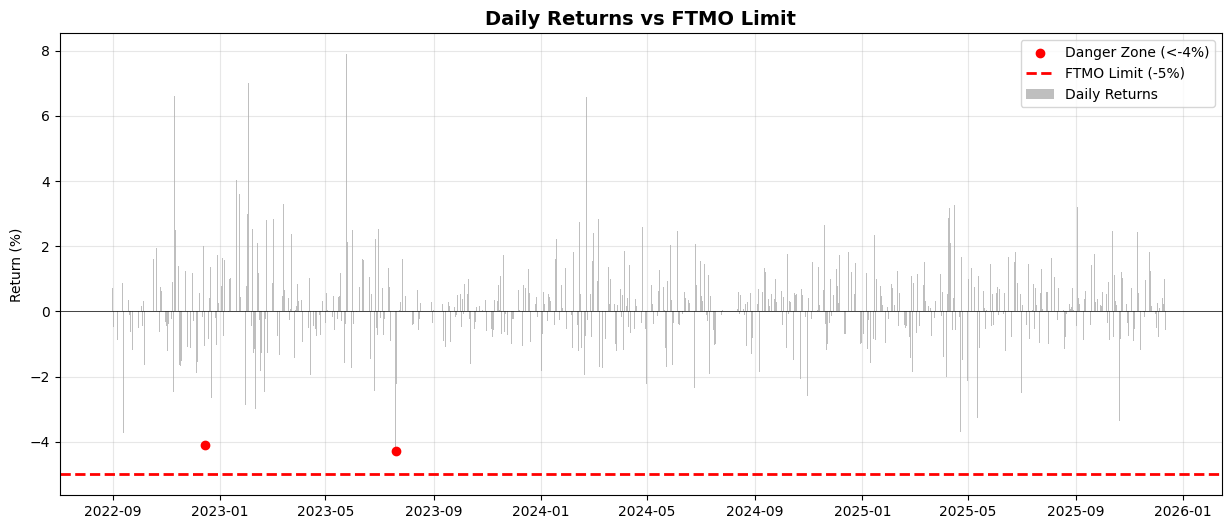

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 9: DAILY DRAWDOWN ANALYSIS (FTMO 5% RULE CHECK)
# ============================================================

print("="*80)
print("STEP 9: ANALISI RISCHIO GIORNALIERO (REGOLA 5%)")
print("="*80)

# 1. Ordiniamo i ritorni dal peggiore al migliore
# returns contiene già i ritorni netti percentuali giornalieri
worst_days = returns.sort_values(ascending=True).head(15)

# 2. Parametro Limite FTMO
DAILY_LIMIT = -0.05  # -5.00%

print(f"📉 I 15 GIORNI PEGGIORI (Soglia critica: {DAILY_LIMIT:.1%}):")
print("-" * 65)
print(f"{'Date':<12} {'Return':>10} {'Status':>15} {'Cause (Probabile)'}")
print("-" * 65)

violation_count = 0

for date, ret in worst_days.items():
    date_str = date.strftime('%Y-%m-%d')
    
    # Check violazione
    if ret <= DAILY_LIMIT:
        status = "❌ VIOLATION"
        violation_count += 1
    elif ret <= -0.04:
        status = "⚠️ WARNING"
    else:
        status = "✅ SAFE"
        
    # Cerchiamo di capire quale asset ha causato il crollo quel giorno
    # Guardiamo chi aveva il peso maggiore e un ritorno negativo
    cause = "N/A"
    try:
        # Recupera pesi e ritorni di quel giorno specifico dal master df
        if date in combined_df.index:
            day_data = combined_df.loc[date]
            worst_asset_perf = 0
            worst_asset_name = ""
            
            for t in tickers:
                w_col = f'{t}_Weight'
                r_col = f'{t}_Return'
                # Verifica esistenza colonne
                if w_col in allocation_df.columns and r_col in combined_df.columns:
                    # Peso allocato * Ritorno asset
                    w = allocation_df.loc[date, w_col]
                    r = combined_df.loc[date, r_col]
                    
                    # Contributo al portafoglio
                    contrib = w * r
                    if contrib < worst_asset_perf:
                        worst_asset_perf = contrib
                        worst_asset_name = t
            
            if worst_asset_name != "":
                cause = f"{worst_asset_name} (Contrib: {worst_asset_perf:.2%})"
    except Exception as e:
        cause = "Data Error"

    print(f"{date_str:<12} {ret:>9.2%} {status:>15}   {cause}")

print("-" * 65)

# 3. Verdetto Finale
print("\n⚖️ VERDETTO DAILY DRAWDOWN:")
if violation_count > 0:
    print(f"❌ FALLITO. Ci sono {violation_count} giorni che superano il limite del 5%.")
    print("   SOLUZIONE: Devi ridurre la size (es. Top 5 asset invece di 4) o attivare il Filtro Regime.")
else:
    max_daily_loss = worst_days.min()
    buffer = abs(max_daily_loss - DAILY_LIMIT)
    print(f"✅ PASSATO. Il giorno peggiore è stato {max_daily_loss:.2%}.")
    print(f"   Hai ancora un margine di sicurezza del {buffer:.2%} prima di toccare il -5%.")

# 4. Grafico Visuale
plt.figure(figsize=(15, 6))
plt.bar(returns.index, returns * 100, color='gray', alpha=0.5, label='Daily Returns')
# Evidenzia i giorni sotto il -4%
danger_zone = returns[returns <= -0.04]
plt.scatter(danger_zone.index, danger_zone * 100, color='red', label='Danger Zone (<-4%)', zorder=5)

plt.axhline(y=-5, color='red', linestyle='--', linewidth=2, label='FTMO Limit (-5%)')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.title('Daily Returns vs FTMO Limit', fontsize=14, fontweight='bold')
plt.ylabel('Return (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("="*80)

STEP 11: ANALISI DETTAGLIATA ULTIMI 12 MESI (ROLLING YEAR)
📅 Finestra Analisi: 2024-12-16 -> 2025-12-16


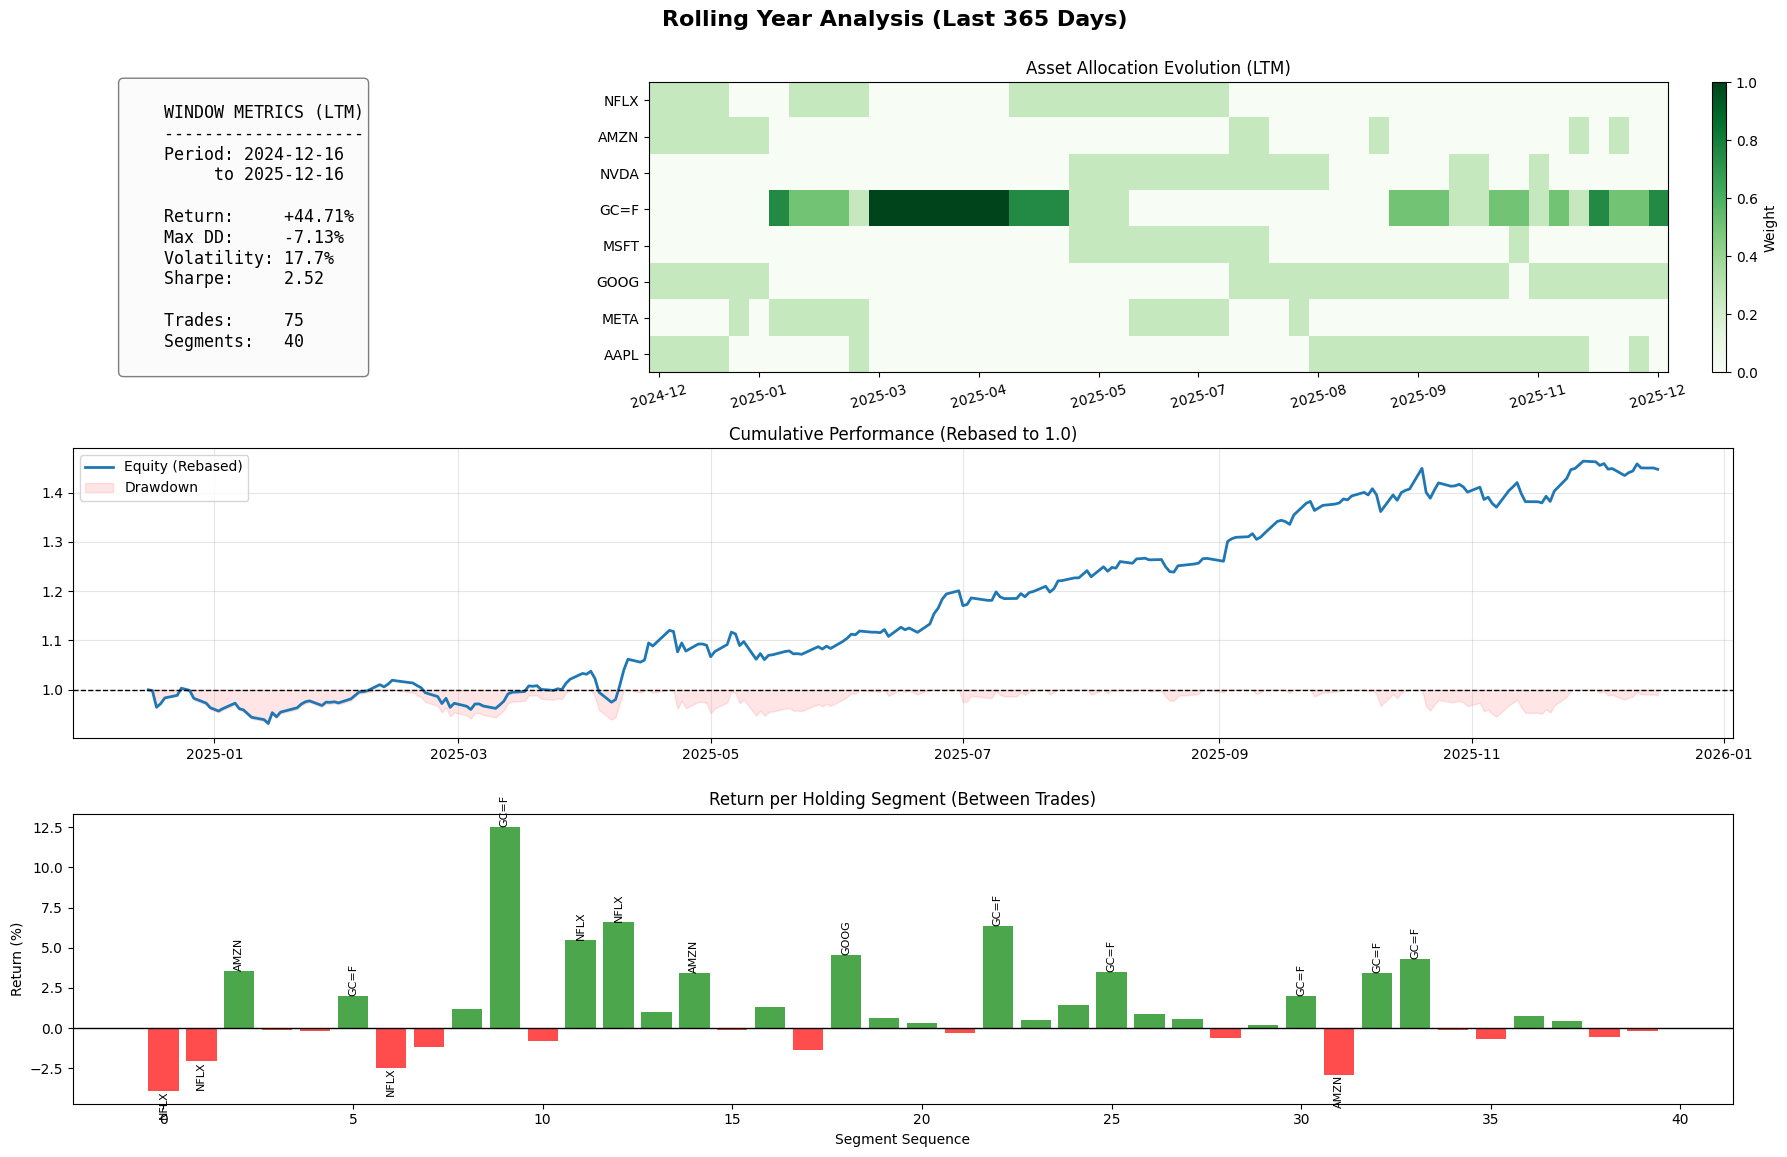


📋 DETTAGLIO SEGMENTI (Performance tra un trade e l'altro):
--------------------------------------------------------------------------------
     Start        End  Days  Return                             Allocation
2024-12-16 2025-01-10    25  -3.87% NFLX 25%, AMZN 25%, GOOG 25%, AAPL 25%
2025-01-10 2025-01-13     3  -2.06% NFLX 25%, AMZN 25%, GOOG 25%, META 25%
2025-01-13 2025-01-24    11  +3.53%           AMZN 25%, GOOG 25%, META 25%
2025-01-24 2025-01-29     5  -0.12%                     AMZN 25%, GOOG 25%
2025-01-29 2025-01-31     2  -0.16%                     AMZN 25%, META 25%
2025-01-31 2025-02-05     5  +2.03%                     GC=F 75%, META 25%
2025-02-05 2025-02-27    22  -2.45%           NFLX 25%, GC=F 50%, META 25%
2025-02-27 2025-03-05     6  -1.18% NFLX 25%, GC=F 25%, META 25%, AAPL 25%
2025-03-05 2025-03-06     1  +1.17%           NFLX 25%, GC=F 50%, META 25%
2025-03-06 2025-04-28    53 +12.52%                              GC=F 100%
2025-04-28 2025-05-15    17  -0.80

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ============================================================
# STEP 11: ROLLING YEAR ANALYSIS (LAST 365 DAYS FOCUS)
# ============================================================

print("="*80)
print("STEP 11: ANALISI DETTAGLIATA ULTIMI 12 MESI (ROLLING YEAR)")
print("="*80)

# 1. Definiamo la finestra temporale
end_date = allocation_df.index[-1]
start_date = end_date - pd.Timedelta(days=365)

# Se lo storico è più breve di un anno, usiamo tutto
if start_date < allocation_df.index[0]:
    start_date = allocation_df.index[0]
    print(f"⚠️ Storico inferiore a 1 anno. Analisi su tutto il periodo ({start_date.date()} -> {end_date.date()})")
else:
    print(f"📅 Finestra Analisi: {start_date.date()} -> {end_date.date()}")

# 2. Filtriamo i dati
window_alloc = allocation_df.loc[start_date:end_date].copy()
window_trades = trade_log[trade_log['Date'] >= start_date].copy() if 'trade_log' in locals() else pd.DataFrame()

if window_alloc.empty:
    print("❌ Dati insufficienti per questa finestra.")
else:
    # 3. Calcolo Segmenti (Periodi tra un rebilanciamento e l'altro)
    # Identifichiamo i giorni in cui c'è stato un cambio di allocazione
    # Usiamo i trade rilevati nello Step 7 come marcatori
    if not window_trades.empty:
        trade_dates = sorted(window_trades['Date'].unique())
    else:
        # Se non ci sono trade, prendiamo solo inizio e fine
        trade_dates = []

    # Aggiungiamo inizio e fine finestra ai punti di taglio
    cut_points = sorted(list(set([start_date, end_date] + [pd.Timestamp(d) for d in trade_dates])))
    
    # Filtriamo date fuori range (sicurezza)
    cut_points = [d for d in cut_points if d >= start_date and d <= end_date]
    
    segments = []
    
    for i in range(len(cut_points) - 1):
        seg_start = cut_points[i]
        seg_end = cut_points[i+1]
        
        # Saltiamo segmenti di 0 giorni
        if seg_start == seg_end: continue
        
        # Ritorni in questo segmento
        # Nota: usiamo slice [seg_start : seg_end]
        seg_returns = window_alloc.loc[seg_start:seg_end, 'Portfolio_Return_After_Commission']
        
        if len(seg_returns) < 1: continue

        # Performance del segmento
        seg_perf = (1 + seg_returns).prod() - 1
        days = (seg_end - seg_start).days
        
        # Allocazione durante questo segmento (prendiamo il primo giorno)
        # Costruiamo stringa descrittiva
        pos_list = []
        for t in tickers:
            w = window_alloc.loc[seg_start, f'{t}_Weight']
            if w > 0.05: # Solo posizioni rilevanti
                pos_list.append(f"{t} {w:.0%}")
        
        alloc_str = ", ".join(pos_list) if pos_list else "CASH/FLAT"
        
        segments.append({
            'Start': seg_start,
            'End': seg_end,
            'Days': days,
            'Return': seg_perf,
            'Allocation': alloc_str
        })
    
    segment_df = pd.DataFrame(segments)

    # 4. Metriche della Finestra
    cum_perf = (1 + window_alloc['Portfolio_Return_After_Commission']).cumprod()
    # Rebase a 1.0 per il grafico
    cum_perf_rebased = cum_perf / cum_perf.iloc[0]
    
    win_dd = cum_perf_rebased / cum_perf_rebased.cummax() - 1
    win_max_dd = win_dd.min()
    win_total_ret = cum_perf_rebased.iloc[-1] - 1
    
    win_vol = window_alloc['Portfolio_Return_After_Commission'].std() * np.sqrt(252)
    win_sharpe = (win_total_ret / win_vol) if win_vol > 0 else 0 # Approx per l'anno

    # =========================================================
    # VISUALIZZAZIONE DASHBOARD (GRIDSPEC)
    # =========================================================
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('Rolling Year Analysis (Last 365 Days)', fontsize=16, fontweight='bold', y=0.96)
    
    # Layout griglia
    gs = GridSpec(3, 3, figure=fig, height_ratios=[1, 1, 1])

    # A) Metriche Testuali (Top Left)
    ax_text = fig.add_subplot(gs[0, 0])
    ax_text.axis('off')
    metrics_str = f"""
    WINDOW METRICS (LTM)
    --------------------
    Period: {start_date.date()}
         to {end_date.date()}
    
    Return:     {win_total_ret:+.2%}
    Max DD:     {win_max_dd:.2%}
    Volatility: {win_vol:.1%}
    Sharpe:     {win_sharpe:.2f}
    
    Trades:     {len(window_trades)}
    Segments:   {len(segment_df)}
    """
    ax_text.text(0.1, 0.5, metrics_str, fontsize=12, family='monospace', va='center', 
                 bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.5))

    # B) Heatmap Allocazione (Top Right - Spalmata su 2 colonne)
    ax_hm = fig.add_subplot(gs[0, 1:])
    
    # Prepariamo dati per heatmap (Solo ultimo anno)
    # Campioniamo ogni 5 giorni per leggibilità se il periodo è lungo, o giornaliero
    resample_step = max(1, len(window_alloc) // 50) 
    hm_data = window_alloc.iloc[::resample_step][[f'{t}_Weight' for t in tickers]].T
    
    # Plot
    im = ax_hm.imshow(hm_data, aspect='auto', cmap='Greens', vmin=0, vmax=1)
    ax_hm.set_yticks(range(len(tickers)))
    ax_hm.set_yticklabels(tickers)
    ax_hm.set_title('Asset Allocation Evolution (LTM)')
    
    # Date sull'asse X
    date_ticks = np.linspace(0, len(hm_data.columns)-1, 10, dtype=int)
    date_labels = [hm_data.columns[i].strftime('%Y-%m') for i in date_ticks]
    ax_hm.set_xticks(date_ticks)
    ax_hm.set_xticklabels(date_labels, rotation=15)
    plt.colorbar(im, ax=ax_hm, label='Weight', fraction=0.02, pad=0.04)

    # C) Equity Curve Rebased (Middle)
    ax_eq = fig.add_subplot(gs[1, :])
    ax_eq.plot(cum_perf_rebased.index, cum_perf_rebased.values, color='#1f77b4', lw=2, label='Equity (Rebased)')
    ax_eq.fill_between(win_dd.index, 1, 1+win_dd, color='red', alpha=0.1, label='Drawdown')
    ax_eq.axhline(1, color='black', ls='--', lw=1)
    ax_eq.set_title('Cumulative Performance (Rebased to 1.0)')
    ax_eq.legend(loc='upper left')
    ax_eq.grid(True, alpha=0.3)

    # D) Segment Returns Bar Chart (Bottom)
    ax_bar = fig.add_subplot(gs[2, :])
    if not segment_df.empty:
        colors = ['green' if x > 0 else 'red' for x in segment_df['Return']]
        ax_bar.bar(range(len(segment_df)), segment_df['Return']*100, color=colors, alpha=0.7)
        ax_bar.axhline(0, color='black', lw=1)
        ax_bar.set_title('Return per Holding Segment (Between Trades)')
        ax_bar.set_ylabel('Return (%)')
        ax_bar.set_xlabel('Segment Sequence')
        # Annotazioni allocazione
        for idx, row in segment_df.iterrows():
            if abs(row['Return']) > 0.02: # Scrivi solo se movimento rilevante
                y_pos = row['Return']*100
                va = 'bottom' if y_pos > 0 else 'top'
                # Prendi solo il primo asset per brevità
                main_asset = row['Allocation'].split(' ')[0] if row['Allocation'] else ""
                ax_bar.text(idx, y_pos, main_asset, ha='center', va=va, fontsize=8, rotation=90)
    else:
        ax_bar.text(0.5, 0.5, "No Segments / Trades", ha='center')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # 5. Stampa Tabella Segmenti (Testo)
    if not segment_df.empty:
        print("\n📋 DETTAGLIO SEGMENTI (Performance tra un trade e l'altro):")
        print("-" * 80)
        # Formattazione
        seg_display = segment_df.copy()
        seg_display['Start'] = seg_display['Start'].dt.date
        seg_display['End'] = seg_display['End'].dt.date
        seg_display['Return'] = seg_display['Return'].map('{:+.2%}'.format)
        
        print(seg_display[['Start', 'End', 'Days', 'Return', 'Allocation']].to_string(index=False))

print("="*80)

STEP 12: SNAPSHOT POSIZIONE CORRENTE & P/L
📅 Data Corrente:          2025-12-16 (Tuesday)
🚀 Inizio Posizione:       2025-12-15 (Monday)
⏳ Giorni a Mercato:       2 trading days (1 calendar days)
💰 P&L Corrente (Net):     -0.19%
----------------------------------------

📦 ALLOCAZIONE ATTUALE:
  🟢 GC=F    75.0% (@ $4304.50)
  🟢 GOOG    25.0% (@ $307.73)

🔄 ULTIMO CAMBIO:
  DA: AMZN, GC=F, GOOG
  A:  GC=F, GOOG


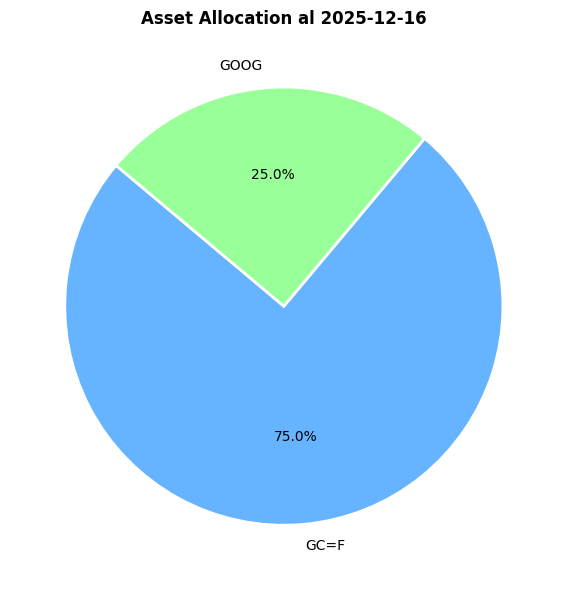

✅ BACKTEST COMPLETATO CON SUCCESSO


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STEP 12: CURRENT POSITION & P/L SNAPSHOT
# ============================================================

print("=" * 80)
print("STEP 12: SNAPSHOT POSIZIONE CORRENTE & P/L")
print("=" * 80)

# 1. Recupera l'ultimo giorno
current_date = allocation_df.index[-1]
weight_cols = [f'{t}_Weight' for t in tickers]

# 2. Identifica l'Allocazione Corrente
current_weights = allocation_df.loc[current_date, weight_cols]
active_weights = current_weights[current_weights > 0.001].sort_values(ascending=False)

# 3. Calcola da quanto tempo deteniamo ESATTAMENTE questo portafoglio
# "Camminiamo all'indietro" nel dataframe finché i pesi non cambiano
start_idx = len(allocation_df) - 1
for i in range(len(allocation_df) - 2, -1, -1):
    date_check = allocation_df.index[i]
    weights_check = allocation_df.loc[date_check, weight_cols]
    
    # Confronto con tolleranza (per evitare errori di virgola mobile)
    if not np.allclose(weights_check.values, current_weights.values, atol=0.01):
        break
    start_idx = i

# La data di inizio di questa posizione è l'indice trovato
position_start_date = allocation_df.index[start_idx]

# 4. Calcola P&L di questo periodo specifico
period_slice = allocation_df.loc[position_start_date:current_date]
if 'Portfolio_Return_After_Commission' in allocation_df.columns:
    period_returns = period_slice['Portfolio_Return_After_Commission']
    cumulative_return = (1 + period_returns).prod() - 1
else:
    cumulative_return = 0.0

trading_days = len(period_slice)
calendar_days = (current_date - position_start_date).days

# 5. Recupera l'allocazione PRECEDENTE
prev_alloc_str = "CASH / START"
if start_idx > 0:
    prev_date = allocation_df.index[start_idx - 1]
    prev_weights = allocation_df.loc[prev_date, weight_cols]
    prev_active = prev_weights[prev_weights > 0.001].index.tolist()
    if prev_active:
        prev_alloc_str = ", ".join([t.replace('_Weight','') for t in prev_active])
    else:
        prev_alloc_str = "CASH"

# 6. STAMPA REPORT
print(f"📅 Data Corrente:          {current_date.strftime('%Y-%m-%d (%A)')}")
print(f"🚀 Inizio Posizione:       {position_start_date.strftime('%Y-%m-%d (%A)')}")
print(f"⏳ Giorni a Mercato:       {trading_days} trading days ({calendar_days} calendar days)")
print(f"💰 P&L Corrente (Net):     {cumulative_return:+.2%}")
print("-" * 40)

print("\n📦 ALLOCAZIONE ATTUALE:")
if active_weights.empty:
    print("  ⚪ CASH (100%)")
else:
    for col, weight in active_weights.items():
        ticker = col.replace('_Weight', '')
        # Recupera prezzo attuale se disponibile
        price_str = ""
        if f'{ticker}_Close' in combined_df.columns:
            price = combined_df.loc[current_date, f'{ticker}_Close']
            price_str = f"(@ ${price:.2f})"
            
        print(f"  🟢 {ticker:<6} {weight:>6.1%} {price_str}")

print("\n🔄 ULTIMO CAMBIO:")
print(f"  DA: {prev_alloc_str}")
cur_str = ", ".join([c.replace('_Weight','') for c in active_weights.index]) if not active_weights.empty else "CASH"
print(f"  A:  {cur_str}")

# 7. VISUALIZZAZIONE (Pie Chart)
if not active_weights.empty:
    plt.figure(figsize=(6, 6))
    # Prepariamo etichette e dati
    labels = [idx.replace('_Weight', '') for idx in active_weights.index]
    sizes = active_weights.values
    
    # Se non somma a 100%, il resto è Cash
    if sizes.sum() < 0.99:
        labels.append('CASH')
        sizes = np.append(sizes, 1.0 - sizes.sum())
    
    colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999', '#c2c2f0'][:len(labels)]
    
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    plt.title(f"Asset Allocation al {current_date.strftime('%Y-%m-%d')}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("=" * 80)
print("✅ BACKTEST COMPLETATO CON SUCCESSO")
print("=" * 80)

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ===============================
# STEP 13: ADVANCED RISK METRICS 
# ===============================

print("=" * 80)
print("STEP 13: ANALISI DEL RISCHIO AVANZATA & MONTE CARLO")
print("=" * 80)

# Recuperiamo i rendimenti giornalieri netti
if 'Portfolio_Return_After_Commission' in allocation_df.columns:
    daily_rets = allocation_df['Portfolio_Return_After_Commission'].fillna(0)
else:
    daily_rets = allocation_df['Portfolio_Return'].fillna(0)

# ------------------------------------------------------------------
# 1) VALUE AT RISK (VaR) & CONDITIONAL VaR (CVaR)
# ------------------------------------------------------------------
# Il VaR ti dice: "Nel 95% dei casi, non perderai più di X% in un giorno"
# Il CVaR (Expected Shortfall) ti dice: "Se le cose vanno MALE (quel 5%), quanto perdi in media?"

var_95 = np.percentile(daily_rets, 5) * 100
var_99 = np.percentile(daily_rets, 1) * 100
cvar_95 = daily_rets[daily_rets <= np.percentile(daily_rets, 5)].mean() * 100

print("🛡️ ANALISI VALUE AT RISK (VaR) - Cruciale per limiti FTMO:")
print(f"  VaR 95% (Giornaliero):      {var_95:.2f}%")
print(f"  VaR 99% (Giornaliero):      {var_99:.2f}%")
print(f"  CVaR 95% (Expected Tail):   {cvar_95:.2f}% (Media delle perdite nei giorni peggiori)")

if abs(var_95) > 4.0:
    print("  ⚠️ ATTENZIONE: Il tuo VaR 95% è vicino al limite del 5%. Rischio elevato.")
else:
    print("  ✅ OK: Il VaR 95% è ben contenuto sotto il limite FTMO.")

# ------------------------------------------------------------------
# 2) EXPECTANCY & PAYOFF
# ------------------------------------------------------------------
# Calcolo basato sui trade (se disponibile) o sui giorni
win_rate = (daily_rets > 0).sum() / len(daily_rets)
avg_win = daily_rets[daily_rets > 0].mean()
avg_loss = daily_rets[daily_rets < 0].mean()
expectancy = (win_rate * avg_win) + ((1 - win_rate) * avg_loss)

print("\n🎲 EXPECTANCY MATEMATICA (Edge):")
print(f"  Win Rate Giornaliero:       {win_rate:.1%}")
print(f"  Avg Win Day:                {avg_win:.2%}")
print(f"  Avg Loss Day:               {avg_loss:.2%}")
print(f"  Expectancy (per giorno):    {expectancy:.4%} (Quanto guadagni 'in media' ogni giorno)")

# Kelly Criterion (Semplificato)
if abs(avg_loss) > 0:
    win_loss_ratio = avg_win / abs(avg_loss)
    kelly_fraction = win_rate - ((1 - win_rate) / win_loss_ratio)
    print(f"  Criterio di Kelly:          {kelly_fraction:.2f} (Leva massima teorica prima della rovina)")
else:
    print("  Criterio di Kelly:          N/A")



STEP 13: ANALISI DEL RISCHIO AVANZATA & MONTE CARLO
🛡️ ANALISI VALUE AT RISK (VaR) - Cruciale per limiti FTMO:
  VaR 95% (Giornaliero):      -1.72%
  VaR 99% (Giornaliero):      -2.85%
  CVaR 95% (Expected Tail):   -2.42% (Media delle perdite nei giorni peggiori)
  ✅ OK: Il VaR 95% è ben contenuto sotto il limite FTMO.

🎲 EXPECTANCY MATEMATICA (Edge):
  Win Rate Giornaliero:       54.4%
  Avg Win Day:                0.94%
  Avg Loss Day:               -0.84%
  Expectancy (per giorno):    0.1244% (Quanto guadagni 'in media' ogni giorno)
  Criterio di Kelly:          0.13 (Leva massima teorica prima della rovina)


STEP 15: SIMULAZIONE MONTE CARLO (LOGICA FEDELE AGLI SCREEN)
⚙️ SETUP:
  Simulazioni: 25000
  Allocazioni: [0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
  Regole: Target +10% | Max Loss -10% | Daily -5%
--------------------------------------------------------------------------------
Avvio simulazioni (questo passaggio richiede qualche secondo)...
  Allocazione 25% -> Pass Rate: 58.9%
  Allocazione 50% -> Pass Rate: 92.2%
  Allocazione 75% -> Pass Rate: 95.9%
  Allocazione 100% -> Pass Rate: 94.3%
  Allocazione 125% -> Pass Rate: 83.0%
  Allocazione 150% -> Pass Rate: 71.8%

📊 MONTE CARLO RESULTS BY ALLOCATION
Alloc    Pass%    Fail Max%  Fail Day%  Timeout%   Avg Days  
-----------------------------------------------------------------
0.25     58.9     0.0        0.0        41.1       175.7     
0.50     92.2     0.2        0.0        7.6        111.5     
0.75     95.9     1.7        0.0        2.4        80.0      
1.00     94.3     5.0        0.0        0.7        60.0      
1.25     83.0     6

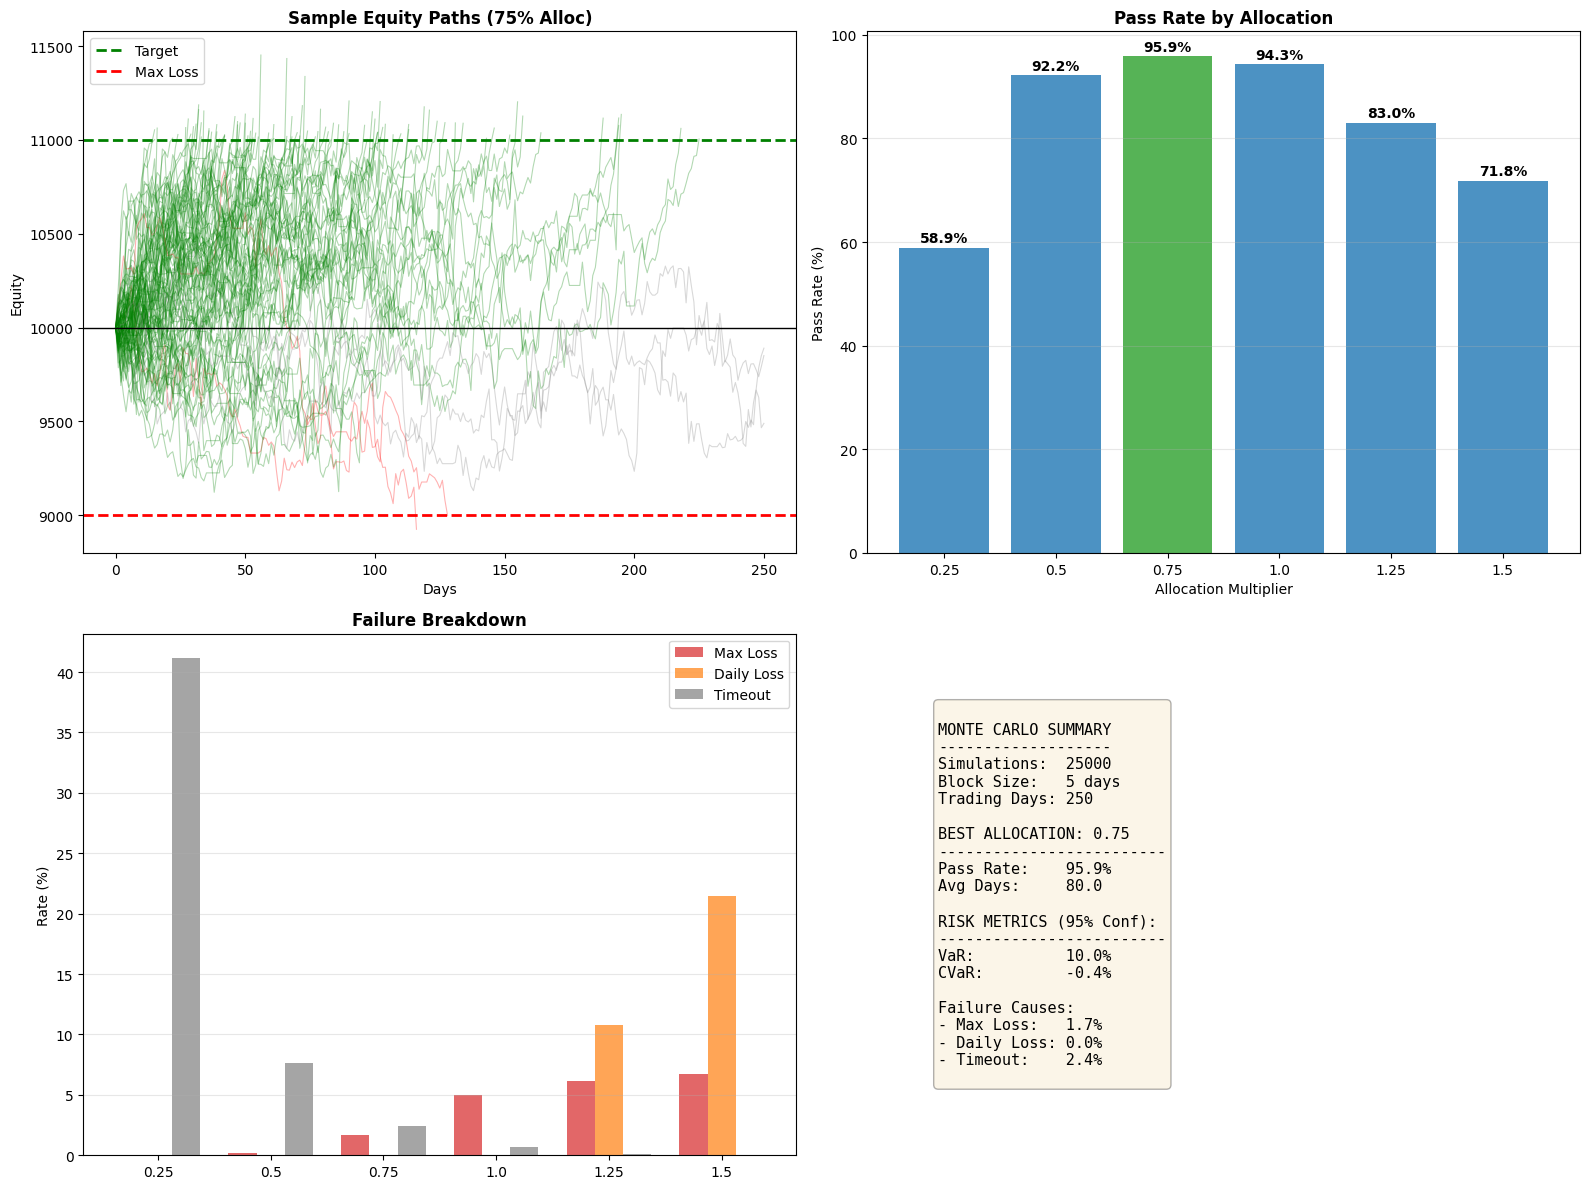

✅ SIMULAZIONE COMPLETATA CON SUCCESSO


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ============================================================
# STEP 15: ENHANCED FTMO MONTE CARLO (Screen-Faithful Version)
# ============================================================

print("=" * 80)
print("STEP 15: SIMULAZIONE MONTE CARLO (LOGICA FEDELE AGLI SCREEN)")
print("=" * 80)

# --- 1. PARAMETRI FTMO (Come da image_adc923.jpg) ---
INITIAL_CAPITAL = 10_000
MAX_LOSS_PCT = 0.10       # 10% Max Loss
PROFIT_TARGET_PCT = 0.10  # 10% Profit Target
MAX_DAILY_LOSS_PCT = 0.05 # 5% Daily Loss

# --- 2. PARAMETRI SIMULAZIONE ---
N_SIMULATIONS = 25_000     # Numero simulazioni (ridotto leggermente per velocità loop)
TRADING_DAYS = 250        # Durata Challenge
BLOCK_SIZE = 5            # Block bootstrap (memoria 1 settimana)
ALLOCATIONS = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5] # Testiamo diverse size
CONFIDENCE_LEVELS = [0.90, 0.95, 0.99]    # Per VaR/CVaR

# --- 3. PREPARAZIONE DATI ---
# Recuperiamo i ritorni reali della tua strategia (Equity Curve)
if 'Portfolio_Return_After_Commission' in allocation_df.columns:
    returns_array_full = allocation_df['Portfolio_Return_After_Commission'].fillna(0).values
else:
    returns_array_full = allocation_df['Portfolio_Return'].fillna(0).values

print(f"⚙️ SETUP:")
print(f"  Simulazioni: {N_SIMULATIONS}")
print(f"  Allocazioni: {ALLOCATIONS}")
print(f"  Regole: Target +{PROFIT_TARGET_PCT:.0%} | Max Loss -{MAX_LOSS_PCT:.0%} | Daily -{MAX_DAILY_LOSS_PCT:.0%}")
print("-" * 80)

# --- 4. FUNZIONE BLOCK BOOTSTRAP (Come da image_adc8cb.jpg) ---
def block_bootstrap(returns, n_days, block_size):
    """Genera un percorso casuale pescando blocchi consecutivi"""
    n_blocks = int(np.ceil(n_days / block_size))
    max_start = len(returns) - block_size
    
    if max_start <= 0: # Fallback se lo storico è troppo breve
        return np.random.choice(returns, size=n_days, replace=True)
    
    sampled = []
    for _ in range(n_blocks):
        start_idx = np.random.randint(0, max_start + 1)
        block = returns[start_idx : start_idx + block_size]
        sampled.extend(block)
        
    return np.array(sampled[:n_days])

# --- 5. ESECUZIONE SIMULAZIONE (Logica loop come image_adc545.jpg) ---
all_results = {}

print("Avvio simulazioni (questo passaggio richiede qualche secondo)...")

for alloc in ALLOCATIONS:
    # Applichiamo l'allocazione (leva simulata)
    scaled_returns = returns_array_full * alloc
    
    # Contatori Risultati
    passed = 0
    failed_max_loss = 0
    failed_daily_loss = 0
    target_not_reached = 0
    
    # Per statistiche e grafici
    final_values = []
    max_drawdowns = []
    days_to_target = []
    equity_paths = [] # Salviamo i primi 50 per il grafico
    
    np.random.seed(42) # Riproducibilità
    
    for sim in range(N_SIMULATIONS):
        # Genera percorso casuale a blocchi
        sim_returns = block_bootstrap(scaled_returns, TRADING_DAYS, BLOCK_SIZE)
        
        equity = INITIAL_CAPITAL
        peak_equity = INITIAL_CAPITAL
        # Reset stato simulazione
        sim_passed = False
        sim_failed = False
        fail_reason = None
        sim_max_dd = 0
        
        path = [equity]
        
        # --- Giorno per Giorno 
        for day, ret in enumerate(sim_returns):
            prev_equity = equity
            equity *= (1 + ret) # Applica ritorno
            path.append(equity)
            
            # Track Drawdown
            peak_equity = max(peak_equity, equity)
            current_dd = (peak_equity - equity) / peak_equity
            sim_max_dd = max(sim_max_dd, current_dd)
            
            # 1. CHECK DAILY LOSS (Regola: Equity non deve scendere sotto equity inizio giornata - 5% capitale iniziale)
            # Nota: FTMO usa spesso "Balance start of day". Qui usiamo Equity start of day.
            daily_loss = (prev_equity - equity) / INITIAL_CAPITAL
            if daily_loss > MAX_DAILY_LOSS_PCT:
                sim_failed = True
                fail_reason = 'daily_loss'
                break # Game Over
                
            # 2. CHECK MAX LOSS (Equity < 90k)
            total_loss = (INITIAL_CAPITAL - equity) / INITIAL_CAPITAL
            if total_loss > MAX_LOSS_PCT:
                sim_failed = True
                fail_reason = 'max_loss'
                break # Game Over
                
            # 3. CHECK PROFIT TARGET (Equity > 110k)
            total_gain = (equity - INITIAL_CAPITAL) / INITIAL_CAPITAL
            if total_gain >= PROFIT_TARGET_PCT:
                sim_passed = True
                days_to_target.append(day + 1)
                break # Win
        
        # Fine percorso simulazione
        if sim < 100: # Salviamo solo i primi 100 per il grafico (altrimenti esplode la RAM)
            equity_paths.append(path)
            
        final_values.append(equity)
        max_drawdowns.append(sim_max_dd)
        
        if sim_passed:
            passed += 1
        elif sim_failed:
            if fail_reason == 'max_loss':
                failed_max_loss += 1
            else:
                failed_daily_loss += 1
        else:
            target_not_reached += 1
            
    # --- Calcolo Statistiche per questa Allocazione ---
    # VaR e CVaR 
    final_rets_pct = (np.array(final_values) / INITIAL_CAPITAL - 1)
    var_dict = {}
    cvar_dict = {}
    for conf in CONFIDENCE_LEVELS:
        cutoff = np.percentile(final_rets_pct, (1 - conf) * 100)
        var_dict[conf] = cutoff
        cvar_dict[conf] = final_rets_pct[final_rets_pct <= cutoff].mean() if len(final_rets_pct[final_rets_pct <= cutoff]) > 0 else cutoff

    all_results[alloc] = {
        'pass_rate': (passed / N_SIMULATIONS) * 100,
        'fail_max_loss_rate': (failed_max_loss / N_SIMULATIONS) * 100,
        'fail_daily_loss_rate': (failed_daily_loss / N_SIMULATIONS) * 100,
        'no_target_rate': (target_not_reached / N_SIMULATIONS) * 100,
        'avg_days': np.mean(days_to_target) if days_to_target else 0,
        'avg_max_dd': np.mean(max_drawdowns) * 100,
        'equity_paths': equity_paths,
        'var': var_dict,
        'cvar': cvar_dict
    }
    
    print(f"  Allocazione {alloc*100:.0f}% -> Pass Rate: {all_results[alloc]['pass_rate']:.1f}%")

# --- 6. VISUALIZZAZIONE RISULTATI 
print("\n📊 MONTE CARLO RESULTS BY ALLOCATION")
print(f"{'Alloc':<8} {'Pass%':<8} {'Fail Max%':<10} {'Fail Day%':<10} {'Timeout%':<10} {'Avg Days':<10}")
print("-" * 65)
for a in ALLOCATIONS:
    r = all_results[a]
    print(f"{a:<8.2f} {r['pass_rate']:<8.1f} {r['fail_max_loss_rate']:<10.1f} {r['fail_daily_loss_rate']:<10.1f} {r['no_target_rate']:<10.1f} {r['avg_days']:<10.1f}")

# Trova la migliore allocazione
best_alloc = max(ALLOCATIONS, key=lambda x: all_results[x]['pass_rate'])
best_res = all_results[best_alloc]

print(f"\n🏆 BEST ALLOCATION: {best_alloc:.2f} ({best_alloc*100:.0f}%)")
print(f"   Pass Rate: {best_res['pass_rate']:.1f}%")
print(f"   Fail Rate: {best_res['fail_max_loss_rate'] + best_res['fail_daily_loss_rate']:.1f}%")

# --- GRAFICI FINALI ---
fig = plt.figure(figsize=(16, 12))

# 1. Equity Paths (Sample)
ax1 = fig.add_subplot(2, 2, 1)
for path in best_res['equity_paths']:
    color = 'green' if path[-1] >= INITIAL_CAPITAL * (1 + PROFIT_TARGET_PCT) else \
            ('red' if path[-1] <= INITIAL_CAPITAL * (1 - MAX_LOSS_PCT) else 'gray')
    ax1.plot(path, color=color, alpha=0.3, lw=0.8)
ax1.axhline(INITIAL_CAPITAL, color='black', lw=1)
ax1.axhline(INITIAL_CAPITAL * (1 + PROFIT_TARGET_PCT), color='green', ls='--', lw=2, label='Target')
ax1.axhline(INITIAL_CAPITAL * (1 - MAX_LOSS_PCT), color='red', ls='--', lw=2, label='Max Loss')
ax1.set_title(f'Sample Equity Paths ({best_alloc*100:.0f}% Alloc)', fontweight='bold')
ax1.set_xlabel('Days')
ax1.set_ylabel('Equity')
ax1.legend(loc='upper left')

# 2. Pass Rate by Allocation
ax2 = fig.add_subplot(2, 2, 2)
rates = [all_results[a]['pass_rate'] for a in ALLOCATIONS]
colors = ['#1f77b4' if a != best_alloc else '#2ca02c' for a in ALLOCATIONS]
bars = ax2.bar([str(a) for a in ALLOCATIONS], rates, color=colors, alpha=0.8)
ax2.set_title('Pass Rate by Allocation', fontweight='bold')
ax2.set_ylabel('Pass Rate (%)')
ax2.set_xlabel('Allocation Multiplier')
ax2.grid(True, axis='y', alpha=0.3)
# Etichette sulle barre
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Failure Breakdown
ax3 = fig.add_subplot(2, 2, 3)
x = np.arange(len(ALLOCATIONS))
width = 0.25
fail_max = [all_results[a]['fail_max_loss_rate'] for a in ALLOCATIONS]
fail_daily = [all_results[a]['fail_daily_loss_rate'] for a in ALLOCATIONS]
no_target = [all_results[a]['no_target_rate'] for a in ALLOCATIONS]

ax3.bar(x - width, fail_max, width, label='Max Loss', color='#d62728', alpha=0.7)
ax3.bar(x, fail_daily, width, label='Daily Loss', color='#ff7f0e', alpha=0.7)
ax3.bar(x + width, no_target, width, label='Timeout', color='#7f7f7f', alpha=0.7)

ax3.set_xticks(x)
ax3.set_xticklabels([str(a) for a in ALLOCATIONS])
ax3.set_title('Failure Breakdown', fontweight='bold')
ax3.set_ylabel('Rate (%)')
ax3.legend()
ax3.grid(True, axis='y', alpha=0.3)

# 4. Summary Text
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')
summary_text = f"""
MONTE CARLO SUMMARY
-------------------
Simulations:  {N_SIMULATIONS}
Block Size:   {BLOCK_SIZE} days
Trading Days: {TRADING_DAYS}

BEST ALLOCATION: {best_alloc:.2f}
-------------------------
Pass Rate:    {best_res['pass_rate']:.1f}%
Avg Days:     {best_res['avg_days']:.1f}

RISK METRICS (95% Conf):
-------------------------
VaR:          {best_res['var'][0.95]:.1%}
CVaR:         {best_res['cvar'][0.95]:.1%}

Failure Causes:
- Max Loss:   {best_res['fail_max_loss_rate']:.1f}%
- Daily Loss: {best_res['fail_daily_loss_rate']:.1f}%
- Timeout:    {best_res['no_target_rate']:.1f}%
"""
ax4.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', va='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("=" * 80)
print("✅ SIMULAZIONE COMPLETATA CON SUCCESSO")
print("=" * 80)

In [124]:
import pandas as pd
import numpy as np

print("="*80)
print("🖨️ GENERATORE DI DATI PER EXCEL (COPIA E INCOLLA)")
print("="*80)
print("\nISTRUZIONI: Seleziona il testo qui sotto (da 'METRICA' in poi), Copia, e Incolla in Excel.")
print("-" * 80)

# --- SEZIONE 1: SOMMARIO E KPI ---
print("SEZIONE 1: KPI GENERALI")
print("METRICA\tVALORE")
print(f"Strategia\tRotational RSI (OOS Test)")
print(f"Periodo Analisi\t{allocation_df.index[0].strftime('%Y-%m-%d')} - {allocation_df.index[-1].strftime('%Y-%m-%d')}")
print(f"Best Allocation (Monte Carlo)\t{best_alloc:.2f} ({best_alloc*100:.0f}%)")
print(f"Pass Rate (Best Alloc)\t{best_res['pass_rate']:.1f}%")
print(f"Fail Rate (Best Alloc)\t{best_res['fail_max_loss_rate'] + best_res['fail_daily_loss_rate']:.1f}%")
# Metriche Portafoglio
total_ret = (1 + returns).prod() - 1
cagr = (1 + total_ret) ** (252 / len(returns)) - 1
vol = returns.std() * np.sqrt(252)
sharpe = cagr / vol if vol != 0 else 0
max_dd = drawdown.min()
win_rate = (returns > 0).sum() / len(returns)

print(f"Total Return\t{total_ret:.2%}")
print(f"CAGR (Annualizzato)\t{cagr:.2%}")
print(f"Sharpe Ratio\t{sharpe:.2f}")
print(f"Max Drawdown\t{max_dd:.2%}")
print(f"Volatility\t{vol:.2%}")
print(f"Win Rate Daily\t{win_rate:.2%}")
print(f"VaR 95% (Daily)\t{np.percentile(returns, 5):.2%}")

print("\n")

# --- SEZIONE 2: RISULTATI MONTE CARLO ---
print("SEZIONE 2: SIMULAZIONE PROP FIRM (MONTE CARLO)")
print("Allocation\tPass Rate\tFail Max Loss\tFail Daily Loss\tTimeout (No Target)")
for alloc in ALLOCATIONS:
    r = all_results[alloc]
    # Usa il punto come decimale per compatibilità, o virgola se il tuo Excel è italiano
    # Qui uso il formato standard internazionale
    print(f"{alloc:.2f}\t{r['pass_rate']:.1f}%\t{r['fail_max_loss_rate']:.1f}%\t{r['fail_daily_loss_rate']:.1f}%\t{r['no_target_rate']:.1f}%")

print("\n")

# --- SEZIONE 3: TABELLA MENSILE (PIVOT) ---
print("SEZIONE 3: RENDIMENTI MENSILI")
# Rigeneriamo la tabella mensile al volo per sicurezza
m_rets = returns.resample('M').apply(lambda x: (1 + x).prod() - 1)
years = m_rets.index.year.unique()
months = range(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Header
print("Year\t" + "\t".join(month_names) + "\tTOTAL")

for year in years:
    line = [str(year)]
    year_data = m_rets[m_rets.index.year == year]
    year_tot = (1 + year_data).prod() - 1
    
    for month in months:
        mask = (m_rets.index.year == year) & (m_rets.index.month == month)
        if mask.any():
            val = m_rets[mask].values[0]
            line.append(f"{val:.2%}")
        else:
            line.append("-")
    
    line.append(f"{year_tot:.2%}")
    print("\t".join(line))

print("\n")

# --- SEZIONE 4: STATISTICHE ANNUALI ---
print("SEZIONE 4: PERFORMANCE ANNUALE")
print("Year\tReturn\tMax DD\tSharpe")
for year in years:
    y_idx = returns.index.year == year
    y_ret = returns[y_idx]
    if len(y_ret) > 0:
        tot = (1 + y_ret).prod() - 1
        # Calcolo DD annuale
        cum = (1 + y_ret).cumprod()
        dd = (cum / cum.cummax() - 1).min()
        # Sharpe Annuale
        std = y_ret.std() * np.sqrt(252)
        shp = tot / std if std > 0 else 0
        
        print(f"{year}\t{tot:.2%}\t{dd:.2%}\t{shp:.2f}")

print("\n")
print("="*80)
print("FINE OUTPUT - COPIA FINO A QUI")
print("="*80)

🖨️ GENERATORE DI DATI PER EXCEL (COPIA E INCOLLA)

ISTRUZIONI: Seleziona il testo qui sotto (da 'METRICA' in poi), Copia, e Incolla in Excel.
--------------------------------------------------------------------------------
SEZIONE 1: KPI GENERALI
METRICA	VALORE
Strategia	Rotational RSI (OOS Test)
Periodo Analisi	2022-09-01 - 2025-12-16
Best Allocation (Monte Carlo)	0.75 (75%)
Pass Rate (Best Alloc)	96.4%
Fail Rate (Best Alloc)	1.7%
Total Return	271.38%
CAGR (Annualizzato)	49.23%
Sharpe Ratio	2.52
Max Drawdown	-16.82%
Volatility	19.52%
Win Rate Daily	54.24%
VaR 95% (Daily)	-1.72%


SEZIONE 2: SIMULAZIONE PROP FIRM (MONTE CARLO)
Allocation	Pass Rate	Fail Max Loss	Fail Daily Loss	Timeout (No Target)
0.25	63.5%	0.0%	0.0%	36.5%
0.50	93.3%	0.2%	0.0%	6.5%
0.75	96.4%	1.7%	0.0%	1.8%
1.00	94.6%	4.9%	0.0%	0.5%
1.25	84.8%	6.8%	8.3%	0.1%
1.50	70.0%	7.0%	23.1%	0.0%


SEZIONE 3: RENDIMENTI MENSILI
Year	Jan	Feb	Mar	Apr	May	Jun	Jul	Aug	Sep	Oct	Nov	Dec	TOTAL
2022	-	-	-	-	-	-	-	-	-3.26%	1.26%	3.36%	-1.55